**MEMBRES:**
BOUKHETALA ZAINEB, KHELLAS YACINE, GHODBANE ZINEB, ALLOUCHE IMENE, REBHI ASSALA NOUR ELIMANE, DERROUECHE SAMIA, BENYAHIA YAHIA

## Introduction

Les Algorithmes Génétiques (AG) et les Algorithmes de Colonies de Fourmis (ACO) sont des approches de résolution basées sur des métaheuristiques, inspirées respectivement par les principes biologiques de l'évolution naturelle et le comportement collectif des fourmis. Ils constituent des outils puissants pour aborder des problèmes complexes, notamment ceux classés comme NP-difficiles, où les solutions optimales ne sont pas facilement accessibles.

Dans le cadre du problème de coloration de graphe, qui consiste à attribuer des couleurs à chaque sommet d'un graphe de manière à ce que deux sommets adjacents n'aient pas la même couleur, ces algorithmes apportent des contributions significatives. Ils permettent d'approcher le nombre chromatique minimal du graphe tout en équilibrant efficacité, précision et robustesse.

## Plan

Dans ce notebook, on va explorer l'implementation de ces 2 approches et leur adaptation au probleme de coloration de graphe.

Dans un premier temps, nous implémentons un algorithme génétique complet basé sur les étapes classiques : génération d’une population initiale, sélection, croisement, mutation et remplacement. Plusieurs variantes de ces opérateurs sont explorées (roulette, élitisme, croisement uniforme, etc.) et analysées sur des benchmarks DIMACS. Nous étudions notamment l’impact du paramètre mix_prob sur la performance du croisement uniforme, ainsi que l’influence des stratégies de remplacement sur la convergence. Une analyse fine de la fitness, du temps d’exécution et de la diversité génétique est également fournie.

Dans un second temps, nous implémentons un algorithme ACO adapté au problème de coloration. Et un autre ACO, ou après une initialisation avec DSATUR, les fourmis construisent des colorations guidées par des matrices de phéromones entre sommets non adjacents, permettant une construction dynamique de classes de couleurs stables. La version améliorée ACO-DSATUR introduit une sélection dynamique des sommets à colorier selon le degré de saturation, ce qui améliore la qualité des solutions et leur convergence.

Enfin, nous menons une comparaison expérimentale entre les 3 approches (AG, ACO classique et ACO-DSATUR) sur plusieurs graphes standards issus des benchmarks DIMACS, en confrontant leurs performances respectives en termes de temps d’exécution, de nombre de couleurs obtenues et de robustesse algorithmique. Le Recuit Simulé adaptatif est également introduit pour enrichir l’analyse comparative, et puis on a comparé la plus performante (ACO-DSATUR) avec l'heuristique DSATUR sur quelques benchmarks.

## Fonctions utilitaires communes

---



In [ ]:
import random
import requests
import time
import math
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
#fonction recuperation du graphe du website DMACS
def lire_graphe_triangulaire(url_fichier,is_url):
    """
    Lit un fichier DIMACS et convertit le graphe en une matrice triangulaire inférieure.

    :param url_fichier: URL du fichier .col contenant le graphe
    :return: Matrice triangulaire inférieure sous forme de liste de listes
    """
    lignes = []
    if(is_url):
      response = requests.get(url_fichier)
      text = response.text
      lignes = text.split('\n')
    else:
      with open(url_fichier, 'r') as f:
        lignes = f.readlines()

    nb_sommets = 0
    aretes = []

    for ligne in lignes:
        ligne = ligne.strip()
        if ligne.startswith('p'):
            _, _, nb_sommets, _ = ligne.split()
            nb_sommets = int(nb_sommets)
        elif ligne.startswith('e'):
            _, sommet1, sommet2 = ligne.split()
            sommet1, sommet2 = int(sommet1), int(sommet2)
            aretes.append((sommet1, sommet2))

    # Création de la matrice triangulaire inférieure
    matrice_triangulaire = [[0] * (i + 1) for i in range(nb_sommets)]
    for sommet1, sommet2 in aretes:
        sommet1 -= 1  # Ajustement des indices (DIMACS commence à 1)
        sommet2 -= 1
        if sommet1 > sommet2:
            matrice_triangulaire[sommet1][sommet2] = 1
        else:
            matrice_triangulaire[sommet2][sommet1] = 1

    return matrice_triangulaire, nb_sommets

In [ ]:
def neighbors_of(node, matrice):
  neighbors = set()
  for j in range(node):
    if matrice[node][j] == 1:
      neighbors.add(j)
  for j in range(node + 1, len(matrice)):
    if matrice[j][node] == 1:
      neighbors.add(j)
  return neighbors

In [ ]:
#solution aléatoire (non basé sur une heuristique ou quoi que ce soit)
def initialize_solution(num_vertices, chromatic_number):
    """
    Generates a random vertex coloring.

    :param num_vertices: Number of vertices in the graph
    :param chromatic_number: Graph's chromatic number
    :return: Random initial coloring
    """
    return [random.randint(1, chromatic_number) for _ in range(num_vertices)]

In [ ]:
# Injecter activement de nouvelles couleurs (au moins quelques-unes)
def inject_new_colors(coloring, target_colors, inject_rate=0.2):
     new_coloring = coloring[:]
     for i in range(len(new_coloring)):
         if random.random() < inject_rate:
            new_coloring[i] = random.randint(1, target_colors)
            return new_coloring

In [ ]:
#solution aléatoire (non basé sur une heuristique ou quoi que ce soit)
def random_solution(num_vertices):
    """
    Generates a random vertex coloring.

    :param num_vertices: Number of vertices in the graph
    :return: Random initial coloring
    """
    return [random.randint(1, num_vertices) for _ in range(num_vertices)]

In [ ]:
#combien de sommets adjacents ont la même couleur
def calculate_conflicts(adj_matrix, num_vertices, coloring):
    """
    Calculates the number of coloring conflicts (edges with same color at both ends).

    :param adj_matrix: Graph adjacency matrix
    :param num_vertices: Number of vertices in the graph
    :param coloring: Current vertex coloring
    :return: Total number of conflicts
    """
    conflicts = 0
    for i in range(num_vertices):
        for j in range(i):
            if adj_matrix[i][j] == 1 and coloring[i] == coloring[j]:
                conflicts += 1
    return conflicts


In [ ]:
def generate_neighbor(coloring, chromatic_number):
    """
    Generates a neighboring solution by randomly changing one vertex's color.

    :param coloring: Current coloring
    :param chromatic_number: Number of available colors
    :return: New neighboring coloring
    """
    neighbor = coloring.copy()
    vertex = random.randint(0, len(coloring) - 1)
    current_color = neighbor[vertex]

    # Choose a new different color
    new_color = current_color
    while new_color == current_color:
        new_color = random.randint(1, chromatic_number)

    neighbor[vertex] = new_color
    return neighbor

In [ ]:
def calculate_fitness(adj_matrix, num_vertices, coloring):
    """
    Calculates fitness based on the number of non-conflicting vertices.
    Higher fitness is better.

    :param adj_matrix: Graph's adjacency matrix.
    :param num_vertices: Total number of vertices in the graph.
    :param coloring: List of assigned colors to vertices.
    :return: Fitness score (higher is better).
    """
    return num_vertices - calculate_conflicts(adj_matrix, num_vertices, coloring)


In [ ]:
#dsatur algorithm four our constructing solutions in ACO
def get_neighbors(node, matrice_triangulaire,n):
        """
        Retourne l'ensemble des voisins du nœud 'node' en utilisant la matrice triangulaire.
        Pour un nœud i, les voisins sont ceux :
          - Dans la même ligne pour les indices j < i (si matrice[i][j] == 1)
          - Dans les lignes suivantes pour lesquels le nœud i apparaît (si matrice[k][i] == 1 pour k > i)
        """
        neighbors = set()
        # Pour les indices j < node, vérifier la ligne 'node'
        for j in range(node):
            if matrice_triangulaire[node][j] == 1:
                neighbors.add(j)
        # Pour les indices > node, le nœud 'node' se trouve en colonne dans la ligne k
        for k in range(node + 1, n):
            if matrice_triangulaire[k][node] == 1:
                neighbors.add(k)
        return neighbors

def dsatur(matrice_triangulaire):
  start = time.time()
  n = len(matrice_triangulaire)
  voisins = {i: get_neighbors(i, matrice_triangulaire,n) for i in range (n)}
  coloring = [None]*n # affectation initial
  ensemble_saturation = [set() for _ in range(n)] #initialisation des ensembles de saturation de chaque noeud
  degre = [len(voisins[i]) for i in range(n)] # Use a list, not a set
  # tantque on n'a pas fini de colorier otus les noeuds
  while any(color is None for color in coloring): # Loop until all nodes are colored
    non_colories = [i for i in range(n) if coloring[i] is None]
    if not non_colories:
          break
    chosen = max(non_colories, key=lambda x: (len(ensemble_saturation[x]), degre[x]))
    used_colors = {coloring[v] for v in voisins[chosen] if coloring[v] is not None}
    color = 0
    while color in used_colors:
      color += 1
    coloring[chosen] = color
    for v in voisins[chosen]:
        if coloring[v] is None:
            ensemble_saturation[v].add(color)
  chromatic_number = max(coloring) + 1 if coloring else 0
  temps = time.time() - start
  return chromatic_number, coloring, temps

# AG

 L’algorithme commence par générer une population initiale de colorations possibles. À chaque génération, il applique plusieurs étapes : la sélection (choisir les meilleures solutions en fonction de leur fitness), le croisement (combiner des solutions pour créer de nouvelles colorations), la mutation (modifier légèrement certaines solutions pour introduire de la diversité) et le remplacement (former la nouvelle génération en sélectionnant les meilleurs individus parmi les anciens et les nouveaux). Ce processus se répète jusqu’à obtenir une solution sans conflit, ce qui permet d’approcher le nombre chromatique minimal du graphe.

## I. Représentation d'une instance de solution sous forme chromosomique

Dans cette étape, chaque solution possible est représentée sous forme d'un chromosome, où chaque gène correspond à la couleur attribuée à un sommet du graphe. Cela permet de modéliser le problème de manière structurée et de calculer la fitness, qui mesure la qualité de la coloration (moins de conflits entre sommets adjacents).

In [ ]:
class Chromosome:
    def __init__(self, coloring, adj_matrix, num_vertices):
        self.coloring = coloring
        self.fitness = calculate_fitness(adj_matrix, num_vertices, coloring)

    def __hash__(self):
        return hash(tuple(self.coloring))

    def __eq__(self, other):
        return self.coloring == other.coloring

    def __repr__(self):
        return f"Chromosome({self.coloring})"

In [ ]:
def initialize_solutions(matrice, num_vertices, chromatic_number):
    """
    Génère une solution initiale semi-aléatoire en minimisant les conflits dès le départ.

    :param matrice: Matrice d'adjacence du graphe
    :param num_vertices: Nombre de sommets
    :param chromatic_number: Nombre de couleurs disponibles
    :return: Une liste représentant une coloration initiale
    """
    coloring = [-1] * num_vertices  # -1 = non colorié

    for vertex in range(num_vertices):
        # Couleurs utilisées par les voisins
        neighbor_colors = set()
        for neighbor in range(len(matrice[vertex])):  # parcours seulement la taille réelle de la ligne
            if matrice[vertex][neighbor] == 1 and coloring[neighbor] != -1:
                neighbor_colors.add(coloring[neighbor])

        # Couleurs disponibles
        available_colors = [color for color in range(1, chromatic_number + 1) if color not in neighbor_colors]

        if available_colors:
            coloring[vertex] = random.choice(available_colors)
        else:
            # Si toutes les couleurs sont prises, choisir aléatoirement
            coloring[vertex] = random.randint(1, chromatic_number)

    return coloring


In [ ]:
def generate_population(pop_size, adj_matrix, num_vertices, num_chromatique):
    """
    Generates an initial population of chromosomes.

    :param pop_size : Population size (number of chromosomes).
    :param num_vertices : Number of graph vertices.

    :return list: List of randomly generated chromosomes.
    """
    population = []
    for _ in range(pop_size):
        coloring = initialize_solutions(adj_matrix, num_vertices, num_chromatique)
        population.append(Chromosome(coloring, adj_matrix, num_vertices))
    return population

In [ ]:
matrix = matrix = [
    [0],                   # 0
    [1, 0],                # 1 connecté à 0
    [1, 1, 0],             # 2 connecté à 0 et 1
    [0, 1, 1, 0],          # 3 connecté à 1 et 2
    [1, 0, 1, 1, 0],       # 4 connecté à 0, 2 et 3
    [0, 1, 0, 1, 1, 0]     # 5 connecté à 1, 3 et 4
]
num_vertices = len(matrix)

solutions = generate_population(12, matrix,num_vertices,2)
for solution in solutions:
  print(solution.coloring,solution.fitness)

[2, 1, 1, 2, 1, 2] 3
[1, 2, 2, 1, 2, 1] 3
[2, 1, 2, 1, 1, 2] 3
[1, 2, 2, 1, 2, 1] 3
[1, 2, 2, 1, 2, 1] 3
[2, 1, 2, 1, 1, 2] 3
[1, 2, 1, 1, 2, 1] 3
[2, 1, 1, 2, 1, 1] 2
[1, 2, 1, 2, 1, 2] 0
[2, 1, 2, 1, 2, 2] 1
[1, 2, 2, 1, 1, 1] 1
[2, 1, 1, 2, 1, 2] 3


## II. Sélection d'un sous-ensemble de solutions
Plusieurs méthodes de sélection sont explorées pour choisir les solutions prometteuses parmi la population :

Roulette : Les solutions sont choisies proportionnellement à leur fitness, favorisant les plus performantes.

Élitisme : Les meilleures solutions sont directement conservées pour garantir une amélioration constante.

Aléatoire : Des solutions sont sélectionnées de manière aléatoire pour introduire de la diversité.

In [ ]:
def roulette_selection(population, num_chromo):
    """
    Selects a chromosome from the population using roulette wheel selection.
    The probability of selecting a chromosome is proportional to its fitness.

    :param population: List of chromosome objects.
    :param num_chromo: Number of chromosomes to select.
    :return: A selected chromosome.
    """
    selected = []
    remaining_pop = population.copy()

    for _ in range(num_chromo):
        total_fitness = sum(chromo.fitness for chromo in remaining_pop)
        if total_fitness <= 0:  # Handle case where all fitnesses are 0 or negative
            selected.extend(random.sample(remaining_pop, num_chromo - len(selected)))
            break

        probs = [chromo.fitness / total_fitness for chromo in remaining_pop]
        chosen_chromo = random.choices(range(len(remaining_pop)), weights=probs, k=1)[0]
        selected.append(remaining_pop.pop(chosen_chromo))

    return selected

In [ ]:
def elitism_selection(population, num_elites):
    """
    Selects the top N fittest chromosomes (elitism).

    :param population: List of Chromosome instances
    :param num_elites: Number of elites to retain
    :return: List of elite Chromosomes
    """
    sorted_population = sorted(population, key=lambda c: c.fitness, reverse=True)
    return sorted_population[:num_elites]

In [ ]:
def random_selection(population, num_chromo):
    """
    Randomly selects one chromosome from the population.

    :param population: List of Chromosome instances
    :param num_chromo: Number of chromosomes to select
    :return: Random Chromosome
    """
    selected = []
    remaining_pop = population.copy()
    for _ in range(num_chromo):
        chosen = random.choice(remaining_pop)
        selected.append(chosen)
        remaining_pop.remove(chosen)

    return selected

### Test des différentes méthodes
Dans cette cellule, nous allons tester plusieurs méthodes de sélection sur un petit graphe, en générant une population de 12 chromosomes (c’est-à-dire 12 colorations différentes avec des valeurs de fitness variées).


In [ ]:
matrix = [
    [0],
    [1, 0],
    [1, 1, 0],
    [0, 1, 1, 0],
    [1, 0, 1, 0, 0],
    [0, 1, 0, 1, 1, 0],
    [1, 0, 1, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 0]
]

solutions = generate_population(12, matrix,8,4)
print("======== Population ========")
print("|    Coloring    | Fitness |")
for solution in solutions:
  print("| ", solution.coloring, " |   ", solution.fitness, "   |")
print("============================\n")

print("========= Roulette =========")
print("|    Coloring    | Fitness |")
roul_sol = roulette_selection(solutions, 5)
for solution in roul_sol:
  print("| ", solution.coloring, " |   ", solution.fitness, "   |")
print("============================\n")

print("========= Elitism  =========")
print("|    Coloring    | Fitness |")
elitism_sol = elitism_selection(solutions, 5)
for solution in elitism_sol:
  print("| ", solution.coloring, " |   ", solution.fitness, "   |")
print("============================\n")

print("========= Random  =========")
print("|    Coloring    | Fitness |")
random_sol = random_selection(solutions, 5)
for solution in random_sol:
  print("| ", solution.coloring, " |   ", solution.fitness, "   |")
print("============================\n")

======== Population ========
|    Coloring    | Fitness |
|  [3, 2, 1, 3, 2, 1, 4, 1]  |    7    |
|  [2, 1, 4, 3, 1, 4, 3, 2]  |    7    |
|  [4, 1, 2, 3, 1, 2, 2, 4]  |    7    |
|  [4, 1, 3, 4, 1, 2, 2, 3]  |    8    |
|  [1, 4, 2, 3, 3, 1, 4, 2]  |    8    |
|  [3, 4, 1, 3, 4, 2, 2, 1]  |    8    |
|  [2, 1, 4, 2, 3, 4, 1, 3]  |    8    |
|  [1, 4, 3, 1, 2, 3, 4, 2]  |    8    |
|  [3, 2, 1, 4, 2, 3, 2, 1]  |    7    |
|  [1, 4, 2, 3, 4, 2, 3, 1]  |    7    |
|  [3, 1, 4, 2, 2, 3, 1, 4]  |    8    |
|  [1, 4, 2, 1, 3, 2, 4, 3]  |    8    |

========= Roulette =========
|    Coloring    | Fitness |
|  [3, 2, 1, 3, 2, 1, 4, 1]  |    7    |
|  [1, 4, 2, 1, 3, 2, 4, 3]  |    8    |
|  [3, 1, 4, 2, 2, 3, 1, 4]  |    8    |
|  [2, 1, 4, 3, 1, 4, 3, 2]  |    7    |
|  [2, 1, 4, 2, 3, 4, 1, 3]  |    8    |

========= Elitism  =========
|    Coloring    | Fitness |
|  [4, 1, 3, 4, 1, 2, 2, 3]  |    8    |
|  [1, 4, 2, 3, 3, 1, 4, 2]  |    8    |
|  [3, 4, 1, 3, 4, 2, 2, 1]  |    8    |
|  [

**Analyse comparative sur des benchmarks issus du site dmacs**
Dans ce qui suit, nous allons générer plusieurs graphes de comparaison basés sur des benchmarks provenant du site dmacs. Les comparaisons porteront sur plusieurs aspects :

* **Temps d'exécution :** comparaison du temps pris par chaque méthode.

* **Fitness moyenne :** pour un nombre fixe d'itérations, comparaison du rapport entre le nombre de nœuds et la fitness obtenue.

* **Évolution de la fitness :** pour chaque benchmark, nous comparons l'évolution de la fitness au fil des générations (ou itérations de sélection).

**Paramètres expérimentaux**

* **Nombre d’itérations :** 5 répétitions par méthode de sélection.

* **Taille de la population :** 100 chromosomes par génération.

* **Stratégie de sélection :** à chaque itération, on sélectionne successivement max(population_size // 2, 2) chromosomes jusqu’à ce qu’il ne reste que les deux derniers à sélectionner.



In [ ]:
def run_selection_benchmark(graph_name, chromatic_number, selection_method, pop_size=100, runs=5):

    matrix, num_nodes = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph_name}.col", True)

    time_results = []
    fitness_results = []
    progressive_fitness = defaultdict(list)  # Tracks fitness per iteration

    for _ in range(runs):
        population = generate_population(pop_size, matrix, num_nodes, chromatic_number)
        selected = []
        remaining_pop = population.copy()
        iteration = 0
        start_time = time.time()

        while len(remaining_pop) > max(len(population)//2, 2):
            # Selection
            if selection_method == "roulette":
                new_selected = roulette_selection(remaining_pop, 1)
            elif selection_method == "elitism":
                new_selected = elitism_selection(remaining_pop, 1)
            else:
                new_selected = random_selection(remaining_pop, 1)

            selected.extend(new_selected)
            remaining_pop = [ind for ind in remaining_pop if ind not in selected]

            # Record fitness at this iteration
            progressive_fitness[iteration].extend([ind.fitness for ind in new_selected])
            iteration += 1

        time_results.append(time.time() - start_time)
        fitness_results.append(max(ind.fitness for ind in selected))

    # Calculate progressive averages
    avg_progressive = {
        it: np.mean(fitnesses)
        for it, fitnesses in progressive_fitness.items()
    }

    return {
        'avg_time': np.mean(time_results),
        'avg_fitness': np.mean(fitness_results),
        'std_fitness': np.std(fitness_results),
        'progressive_fitness': avg_progressive  # Added
    }


In [ ]:
# ================== MAIN BENCHMARK EXECUTION ==================
graphs_best = {
    "dsjc125.9": 44,
    "dsjc125.1": 5,
    "dsjc250.1": 8,
    "r250.1": 8,
    "flat300_28_0": 28,
    "le450_25c": 25
}

results = defaultdict(dict)
progressive_data = defaultdict(dict)  # Stores progressive fitness per graph/method

for graph, k in graphs_best.items():
    for method in ["roulette", "elitism", "random"]:
        print(f"Testing {method} on {graph}...")
        results[graph][method] = run_selection_benchmark(graph, k, method)
        progressive_data[graph][method] = results[graph][method]['progressive_fitness']

Testing roulette on dsjc125.9...
Testing elitism on dsjc125.9...
Testing random on dsjc125.9...
Testing roulette on dsjc125.1...
Testing elitism on dsjc125.1...
Testing random on dsjc125.1...
Testing roulette on dsjc250.1...
Testing elitism on dsjc250.1...
Testing random on dsjc250.1...
Testing roulette on r250.1...
Testing elitism on r250.1...
Testing random on r250.1...
Testing roulette on flat300_28_0...
Testing elitism on flat300_28_0...
Testing random on flat300_28_0...
Testing roulette on le450_25c...
Testing elitism on le450_25c...
Testing random on le450_25c...


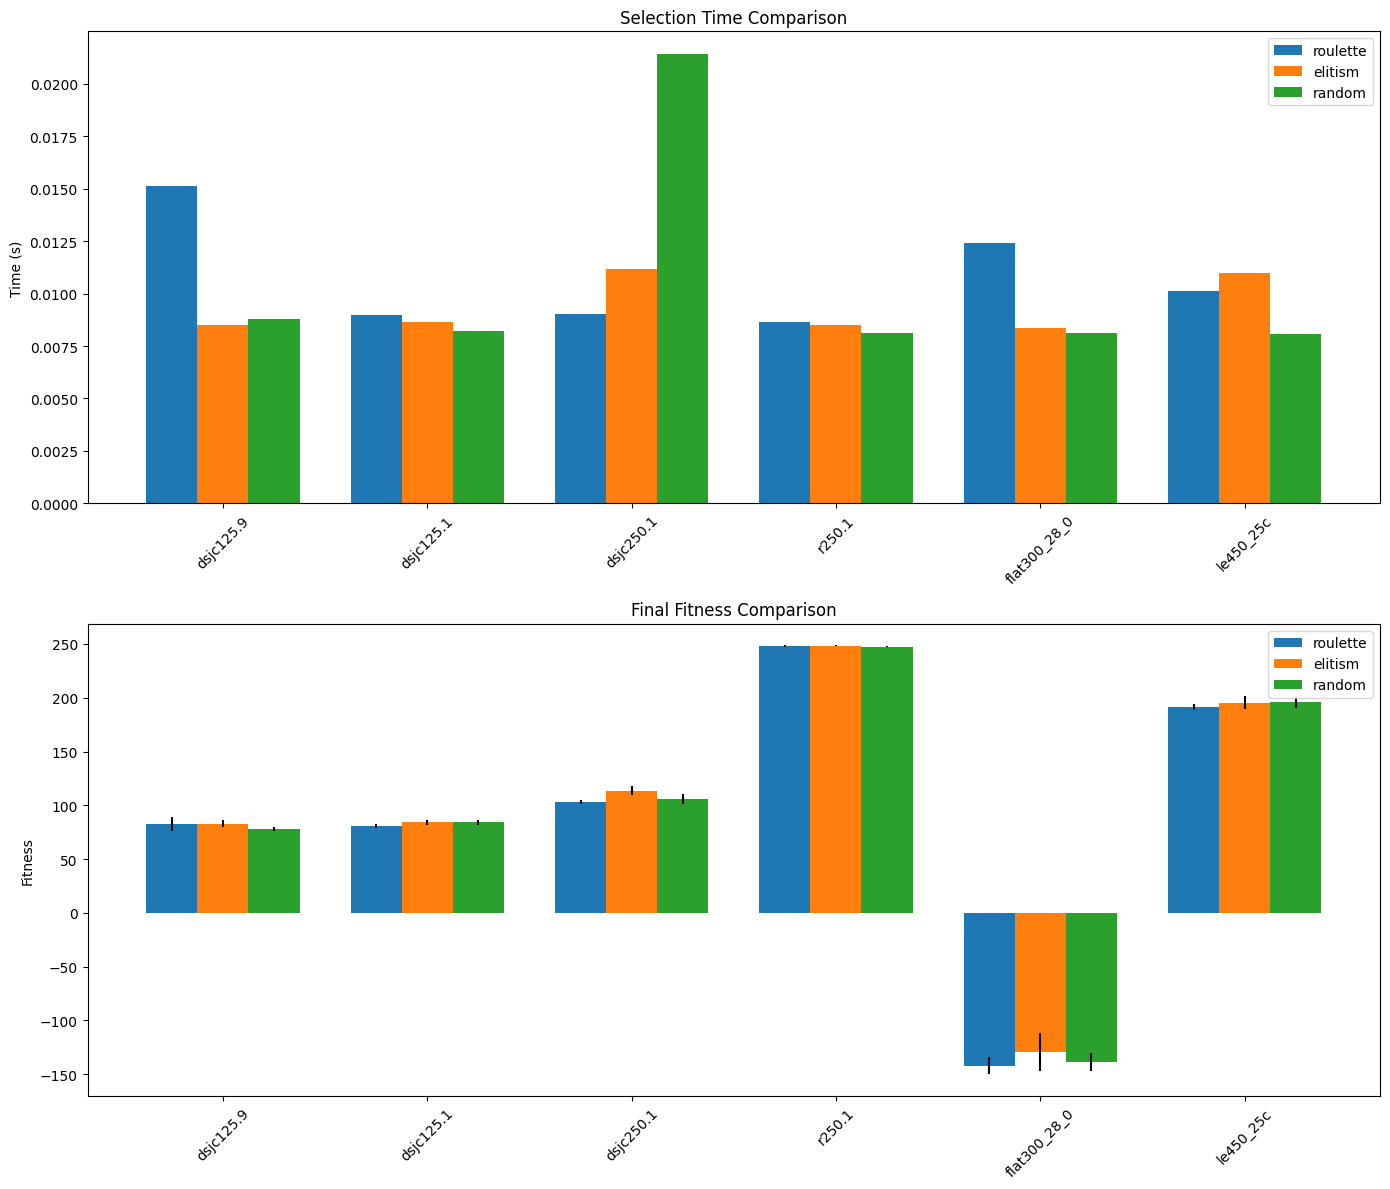

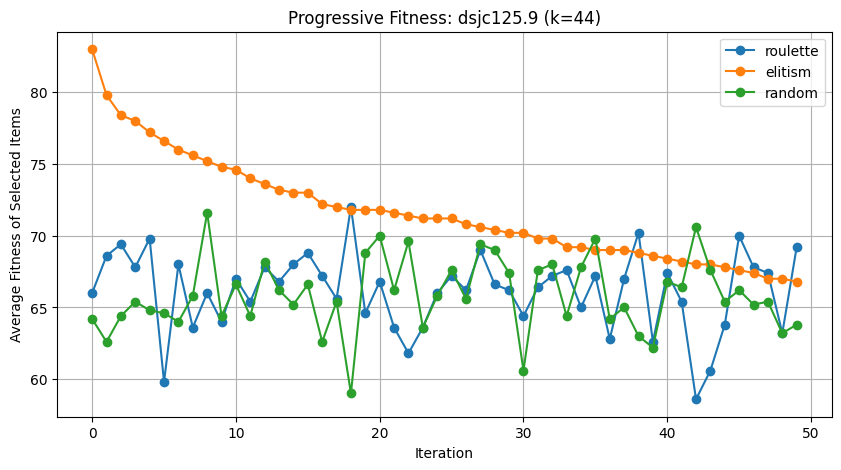

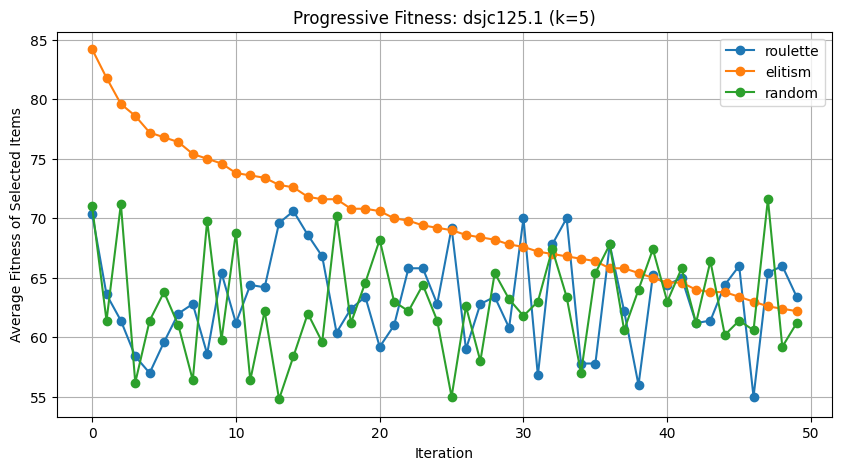

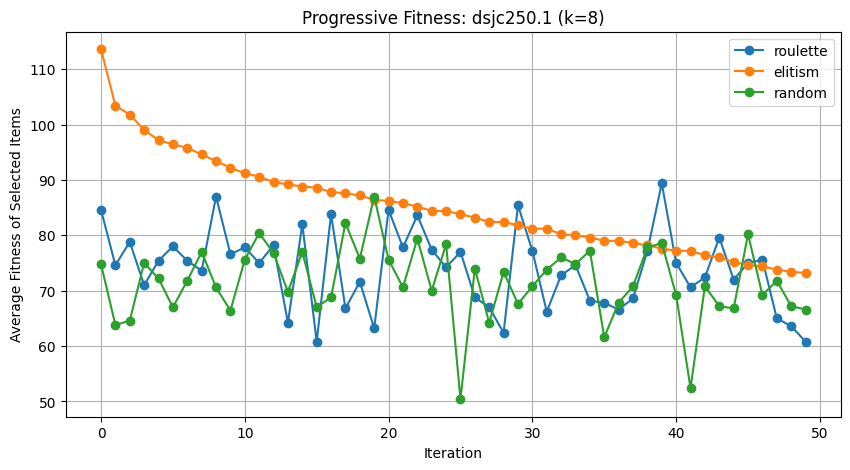

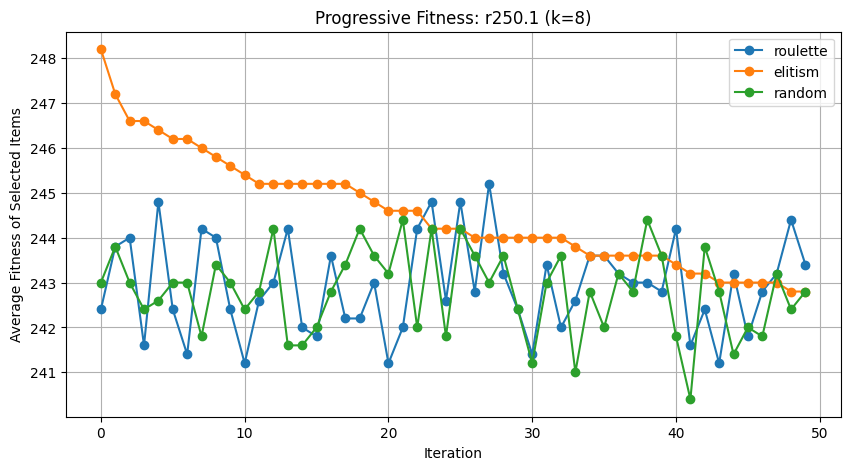

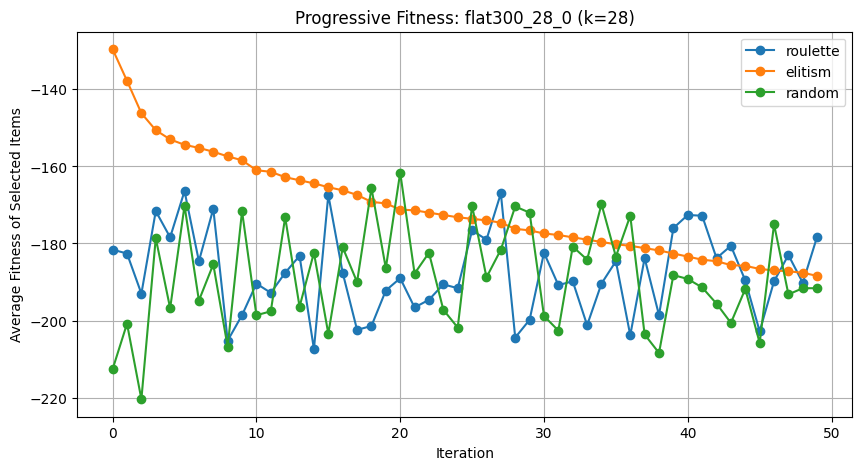

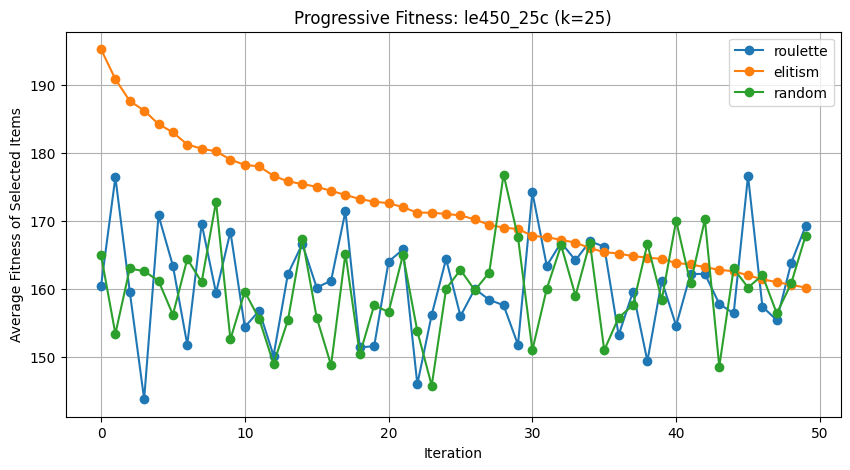

In [ ]:
# ================== PLOTTING ==================
# 1. Time/Fitness Comparison (Original)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Time plot
x = np.arange(len(graphs_best))
width = 0.25
methods = ["roulette", "elitism", "random"]

for i, method in enumerate(methods):
    times = [results[g][method]['avg_time'] for g in graphs_best]
    ax1.bar(x + i*width, times, width, label=method)

ax1.set_title('Selection Time Comparison')
ax1.set_ylabel('Time (s)')
ax1.set_xticks(x + width)
ax1.set_xticklabels(graphs_best.keys(), rotation=45)
ax1.legend()

# Fitness plot
for i, method in enumerate(methods):
    fitness = [results[g][method]['avg_fitness'] for g in graphs_best]
    ax2.bar(x + i*width, fitness, width, label=method,
           yerr=[results[g][method]['std_fitness'] for g in graphs_best])

ax2.set_title('Final Fitness Comparison')
ax2.set_ylabel('Fitness')
ax2.set_xticks(x + width)
ax2.set_xticklabels(graphs_best.keys(), rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# 2. Progressive Fitness Analysis (New)
for graph in graphs_best:
    plt.figure(figsize=(10, 5))
    for method in methods:
        iterations = sorted(progressive_data[graph][method].keys())
        avg_fitness = [progressive_data[graph][method][it] for it in iterations]
        plt.plot(iterations, avg_fitness, label=method, marker='o')

    plt.title(f'Progressive Fitness: {graph} (k={graphs_best[graph]})')
    plt.xlabel('Iteration')
    plt.ylabel('Average Fitness of Selected Items')
    plt.legend()
    plt.grid(True)
    plt.show()

## III. Croisement
Le croisement combine des paires de solutions pour générer de nouveaux individus. Plusieurs types de croisement sont utilisés :

Un seul point : Les chromosomes des parents sont mélangés à partir d'un point spécifique.

Deux points : Deux points de coupure sont définis, créant des segments mélangés.

Uniforme : Chaque gène est choisi de manière aléatoire entre les deux parents, avec une probabilité donnée.

In [ ]:
def one_point_crossover(parent1: Chromosome, parent2: Chromosome, adj_matrix: list[list[int]], num_vertices: int) -> tuple[Chromosome, Chromosome]:
    """
    Effectue un croisement à un point entre deux parents.

    Args:
        parent1 (Chromosome): Premier parent
        parent2 (Chromosome): Deuxième parent
        adj_matrix (list[list[int]]): Matrice d'adjacence du graphe
        num_vertices (int): Nombre de sommets

    Returns:
        tuple[Chromosome, Chromosome]: Deux enfants issus du croisement
    """
    # Récupération des colorations des parents
    p1 = parent1.coloring.copy()
    p2 = parent2.coloring.copy()

    # Sélection aléatoire d'un point de coupure (entre 1 et n-1)
    crossover_point = random.randint(1, num_vertices - 1)

    # Création des enfants
    child1 = p1[:crossover_point] + p2[crossover_point:]
    child2 = p2[:crossover_point] + p1[crossover_point:]

    return Chromosome(child1, adj_matrix, num_vertices), Chromosome(child2, adj_matrix, num_vertices)

In [ ]:
def two_point_crossover(parent1: Chromosome, parent2: Chromosome, adj_matrix: list[list[int]], num_vertices: int) -> tuple[Chromosome, Chromosome]:
    """
    Effectue un croisement à deux points entre deux parents.

    Args:
        parent1 (Chromosome): Premier parent
        parent2 (Chromosome): Deuxième parent
        adj_matrix (list[list[int]]): Matrice d'adjacence du graphe
        num_vertices (int): Nombre de sommets

    Returns:
        tuple[Chromosome, Chromosome]: Deux enfants issus du croisement
    """
    p1 = parent1.coloring.copy()
    p2 = parent2.coloring.copy()

    # Génération de deux points distincts triés
    points = sorted(random.sample(range(num_vertices + 1), 2))
    point1, point2 = points

    # Création des enfants
    child1 = p1[:point1] + p2[point1:point2] + p1[point2:]
    child2 = p2[:point1] + p1[point1:point2] + p2[point2:]

    return Chromosome(child1, adj_matrix, num_vertices), Chromosome(child2, adj_matrix, num_vertices)

In [ ]:
def uniform_crossover(parent1: Chromosome, parent2: Chromosome, adj_matrix: list[list[int]], num_vertices: int, mix_prob: float = 0.5) -> tuple[Chromosome, Chromosome]:
    """
    Effectue un croisement uniforme entre deux parents.

    Args:
        parent1 (Chromosome): Premier parent
        parent2 (Chromosome): Deuxième parent
        adj_matrix (list[list[int]]): Matrice d'adjacence du graphe
        num_vertices (int): Nombre de sommets
        mix_prob (float, optional): Probabilité de prendre le gène du parent1. Defaults to 0.5.

    Returns:
        tuple[Chromosome, Chromosome]: Deux enfants issus du croisement
    """
    p1 = parent1.coloring.copy()
    p2 = parent2.coloring.copy()

    child1 = []
    child2 = []

    # Mélange aléatoire pour chaque gène
    for i in range(num_vertices):
        if random.random() < mix_prob:
            child1.append(p1[i])
            child2.append(p2[i])
        else:
            child1.append(p2[i])
            child2.append(p1[i])

    return Chromosome(child1, adj_matrix, num_vertices), Chromosome(child2, adj_matrix, num_vertices)

In [ ]:
def crossover(parent1: Chromosome, parent2: Chromosome, adj_matrix: list[list[int]], num_vertices: int,
             crossover_type: str = 'one_point', **kwargs) -> tuple[Chromosome, Chromosome]:
    """
    Applique l'opérateur de croisement spécifié entre deux parents.

    Args:
        parent1 (Chromosome): Premier parent
        parent2 (Chromosome): Deuxième parent
        adj_matrix (list[list[int]]): Matrice d'adjacence
        num_vertices (int): Nombre de sommets
        crossover_type (str): Type de croisement ('one_point', 'two_point', 'uniform')
        **kwargs: Paramètres additionnels pour le croisement

    Returns:
        tuple[Chromosome, Chromosome]: Les deux enfants produits
    """
    if crossover_type == 'one_point':
        return one_point_crossover(parent1, parent2, adj_matrix, num_vertices)
    elif crossover_type == 'two_point':
        return two_point_crossover(parent1, parent2, adj_matrix, num_vertices)
    elif crossover_type == 'uniform':
        mix_prob = kwargs.get('mix_prob', 0.5)
        return uniform_crossover(parent1, parent2, adj_matrix, num_vertices, mix_prob)
    else:
        raise ValueError(f"Type de croisement inconnu: {crossover_type}")

### Étude de l'Impact du Paramètre mix_prob sur la Fitness

#### Objectif de l'Étude
Cette expérience vise à comprendre comment le paramètre `mix_prob` (probabilité de sélection des gènes du parent 1) influence la qualité des solutions générées par l'opérateur de croisement uniforme dans le contexte de la coloration de graphes.

### Méthodologie
#### Structure du Code
1. Téléchargement de 6 graphes de référence
2. `mix_prob` testé de 0 à 1 par pas de 0.1
  - 50 essais par valeur pour une moyenne statistiquement significative
- **Mesure** : Fitness moyenne des enfants sur l'ensemble des essais

#### Conclusion
on a remarqué que le paramètre du croisement uniforme `mix_prob` influence la fonction fitness mais pas d'une manière uniforme (aléatoire), chaque graphe a une valeur `mix_prob` unique à lui qui lui maximise la fonction fitness. Autrement dit:
- Aucune valeur de mix_prob n'est universellement optimale
- L'efficacité dépend fortement du graphe et des parents


=== Traitement de dsjc125.9 ===
Téléchargement en cours depuis le serveur...
Graphe chargé (125 sommets) - Début des calculs...
Test mix_prob=0.0 | Test mix_prob=0.1 | Test mix_prob=0.2 | Test mix_prob=0.3 | Test mix_prob=0.4 | Test mix_prob=0.5 | Test mix_prob=0.6 | Test mix_prob=0.7 | Test mix_prob=0.8 | Test mix_prob=0.9 | Test mix_prob=1.0 | 
Calculs terminés !


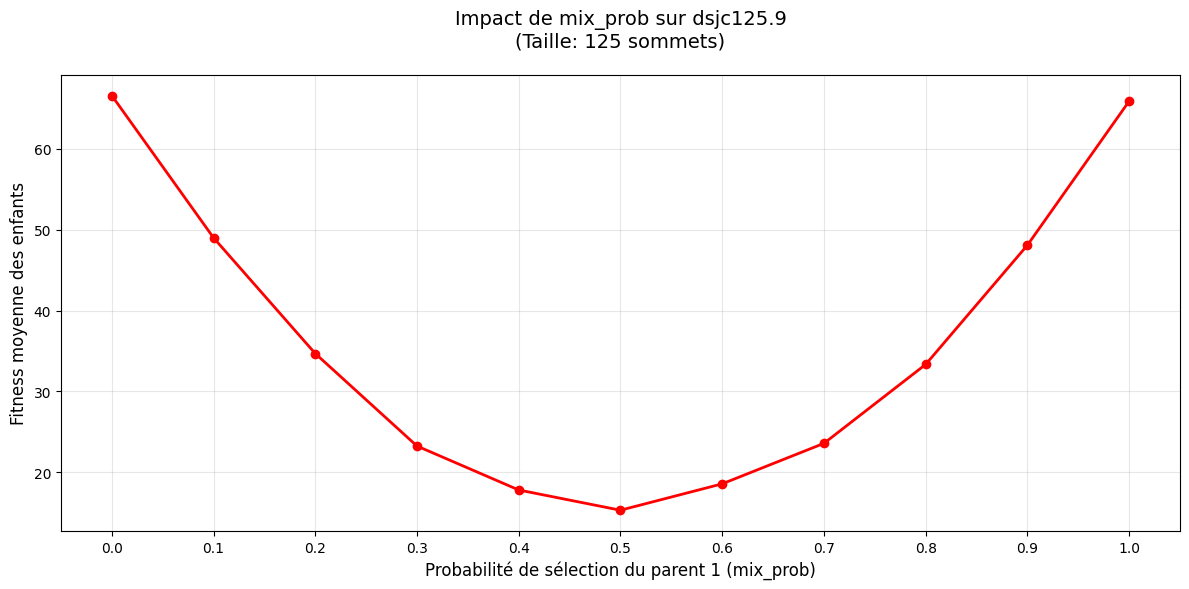


=== Traitement de dsjc125.1 ===
Téléchargement en cours depuis le serveur...
Graphe chargé (125 sommets) - Début des calculs...
Test mix_prob=0.0 | Test mix_prob=0.1 | Test mix_prob=0.2 | Test mix_prob=0.3 | Test mix_prob=0.4 | Test mix_prob=0.5 | Test mix_prob=0.6 | Test mix_prob=0.7 | Test mix_prob=0.8 | Test mix_prob=0.9 | Test mix_prob=1.0 | 
Calculs terminés !


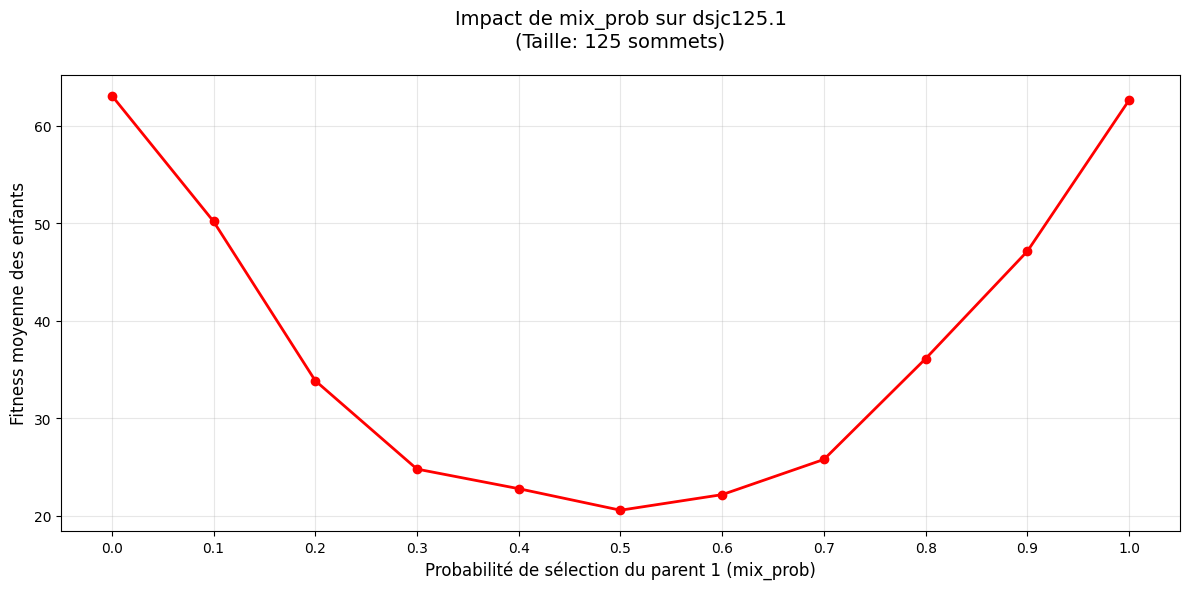


=== Traitement de dsjc250.1 ===
Téléchargement en cours depuis le serveur...
Graphe chargé (250 sommets) - Début des calculs...
Test mix_prob=0.0 | Test mix_prob=0.1 | Test mix_prob=0.2 | Test mix_prob=0.3 | Test mix_prob=0.4 | Test mix_prob=0.5 | Test mix_prob=0.6 | Test mix_prob=0.7 | Test mix_prob=0.8 | Test mix_prob=0.9 | Test mix_prob=1.0 | 
Calculs terminés !


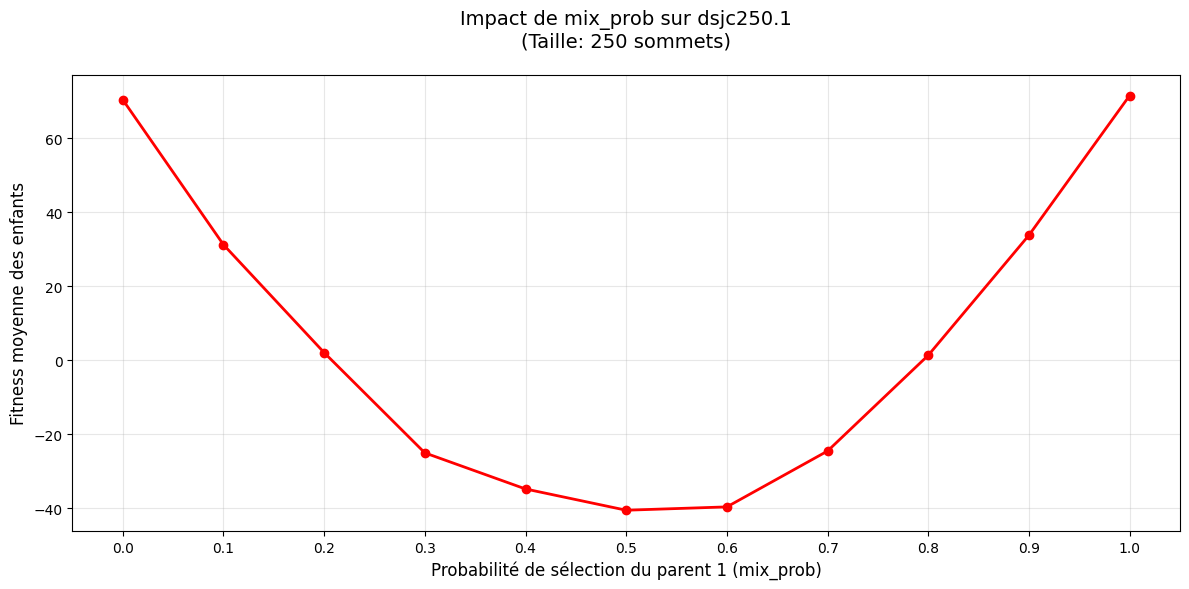


=== Traitement de r250.1 ===
Téléchargement en cours depuis le serveur...
Graphe chargé (250 sommets) - Début des calculs...
Test mix_prob=0.0 | Test mix_prob=0.1 | Test mix_prob=0.2 | Test mix_prob=0.3 | Test mix_prob=0.4 | Test mix_prob=0.5 | Test mix_prob=0.6 | Test mix_prob=0.7 | Test mix_prob=0.8 | Test mix_prob=0.9 | Test mix_prob=1.0 | 
Calculs terminés !


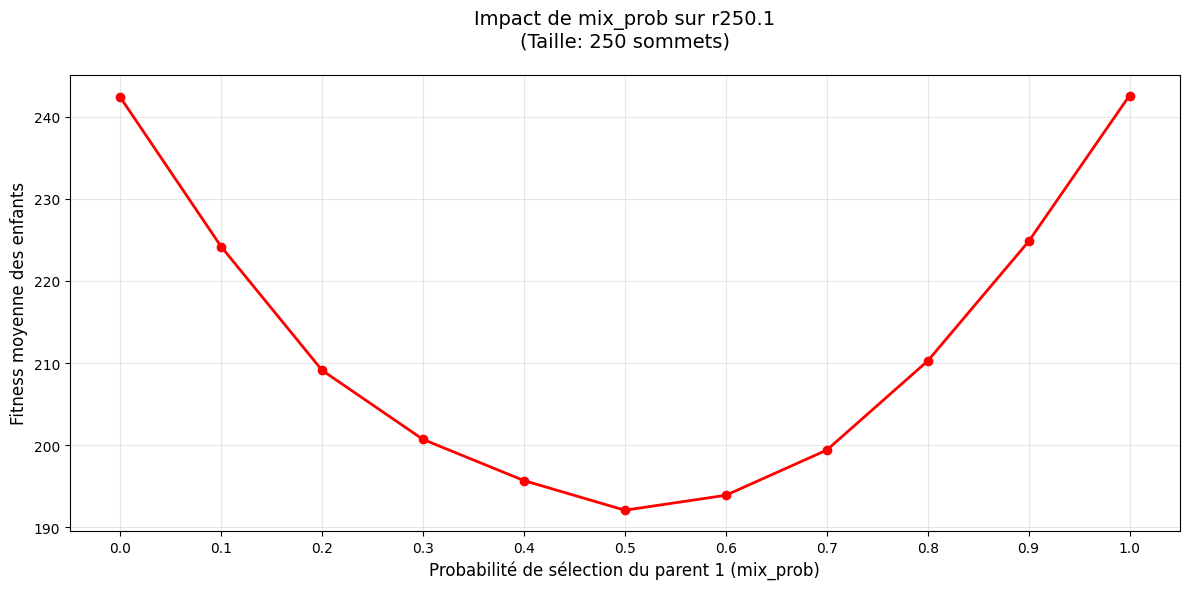


=== Traitement de flat300_28_0 ===
Téléchargement en cours depuis le serveur...
Graphe chargé (300 sommets) - Début des calculs...
Test mix_prob=0.0 | Test mix_prob=0.1 | Test mix_prob=0.2 | Test mix_prob=0.3 | Test mix_prob=0.4 | Test mix_prob=0.5 | Test mix_prob=0.6 | Test mix_prob=0.7 | Test mix_prob=0.8 | Test mix_prob=0.9 | Test mix_prob=1.0 | 
Calculs terminés !


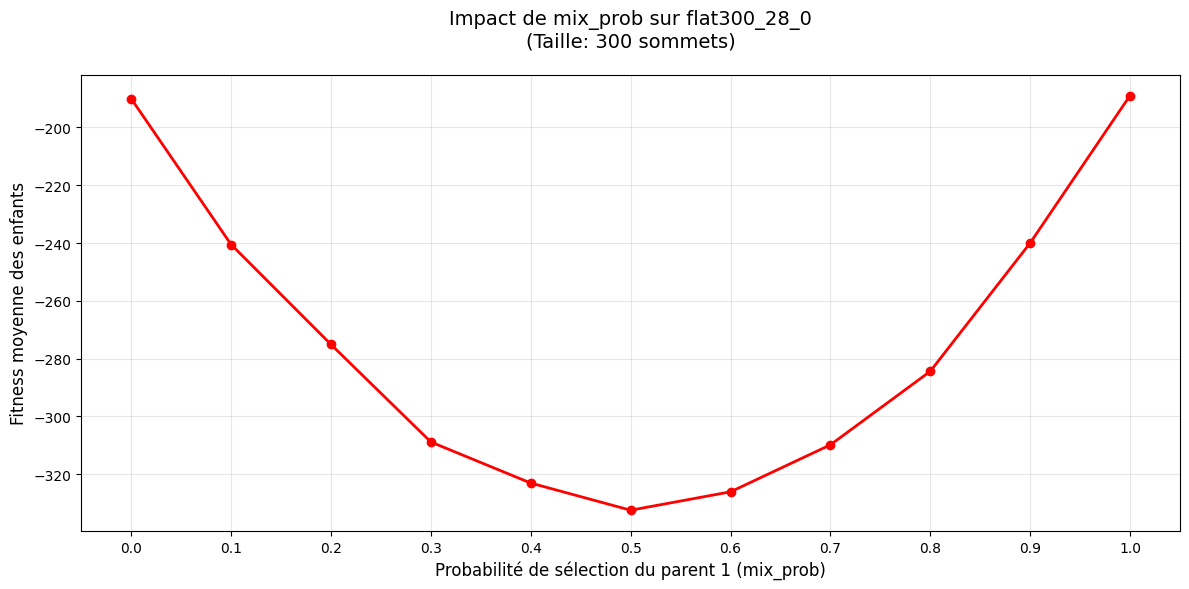


=== Traitement de le450_25c ===
Téléchargement en cours depuis le serveur...
Graphe chargé (450 sommets) - Début des calculs...
Test mix_prob=0.0 | Test mix_prob=0.1 | Test mix_prob=0.2 | Test mix_prob=0.3 | Test mix_prob=0.4 | Test mix_prob=0.5 | Test mix_prob=0.6 | Test mix_prob=0.7 | Test mix_prob=0.8 | Test mix_prob=0.9 | Test mix_prob=1.0 | 
Calculs terminés !


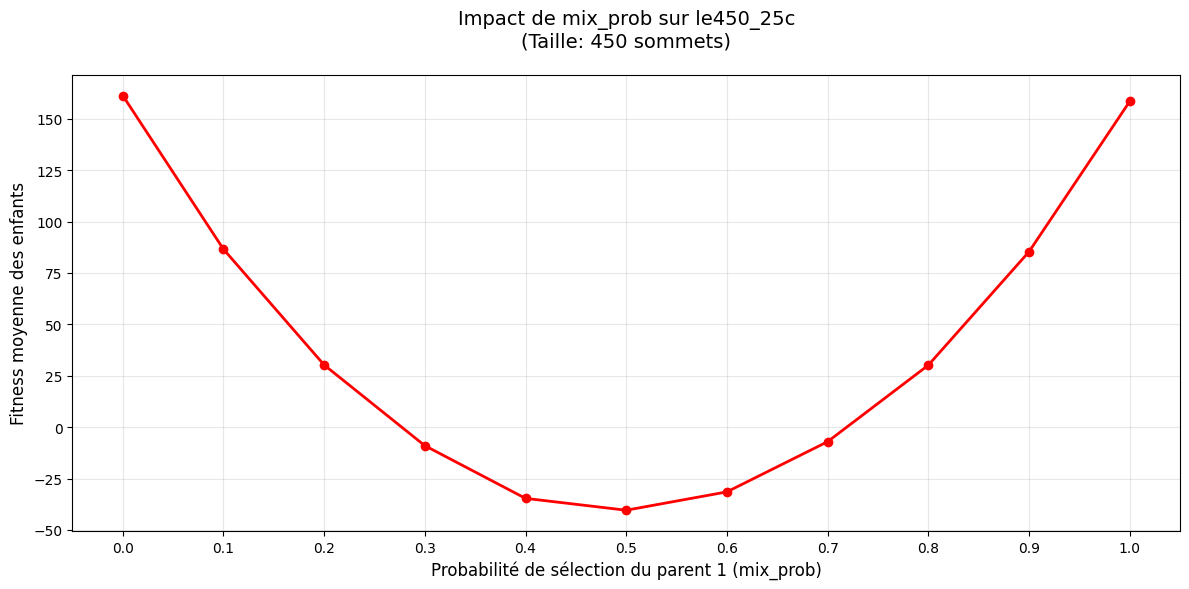

In [ ]:
def study_mix_prob_effect_multigraphs():
    """
    Étudie l'impact de mix_prob sur différents graphes et affiche les graphiques immédiatement
    """
    random.seed(42)
    mix_probs = [i/10 for i in range(11)]
    num_trials = 50
    graphs_bench = {
        "dsjc125.9": 44,
        "dsjc125.1": 5,
        "dsjc250.1": 8,
        "r250.1": 8,
        "flat300_28_0": 28,
        "le450_25c": 25
    }

    for graph_name, best_color in graphs_bench.items():
        print(f"\n=== Traitement de {graph_name} ===")

        try:
            # Chargement du graphe
            print(f"Téléchargement en cours depuis le serveur...")
            adj_matrix, num_vertices = lire_graphe_triangulaire(
                f"https://cedric.cnam.fr/~porumbed/graphs/{graph_name}.col",
                is_url=True
            )
            print(f"Graphe chargé ({num_vertices} sommets) - Début des calculs...")

            # Calcul des résultats
            results = []
            for prob in mix_probs:
                print(f"Test mix_prob={prob:.1f}", end=" | ")
                total = 0
                for _ in range(num_trials):
                    parents = generate_population(2, adj_matrix, num_vertices, best_color)
                    child1, child2 = uniform_crossover(*parents, adj_matrix, num_vertices, prob)
                    total += (child1.fitness + child2.fitness)/2
                results.append(total/num_trials)
            print("\nCalculs terminés !")

            # Création du graphique
            plt.figure(figsize=(12, 6))
            plt.plot(mix_probs, results, 'r-o', linewidth=2)
            plt.title(f"Impact de mix_prob sur {graph_name}\n(Taille: {num_vertices} sommets)", fontsize=14, pad=20)
            plt.xlabel("Probabilité de sélection du parent 1 (mix_prob)", fontsize=12)
            plt.ylabel("Fitness moyenne des enfants", fontsize=12)
            plt.xticks(mix_probs, fontsize=10)
            plt.yticks(fontsize=10)
            plt.grid(True, alpha=0.3)

            # Affichage + sauvegarde
            plt.tight_layout()
            plt.savefig(f"mix_prob_{graph_name}.png", dpi=100)  # Sauvegarde en arrière-plan
            plt.show()  # Affiche la figure immédiatement
            plt.close()

        except Exception as e:
            print(f"/!\ Erreur avec {graph_name}: {str(e)}")
            continue

# Exécutez cette fonction
study_mix_prob_effect_multigraphs()

### Comparaison des Méthodes de Croisement pour la Coloration de Graphes

## Objectif de l'Expérience
Cette analyse compare l'efficacité de trois opérateurs de croisement (One-Point, Two-Point et Uniform) sur différents graphes de référence, avec deux métriques clés :
1. **Fitness des enfants** (qualité de la coloration)
2. **Similarité génétique** avec les parents (pourcentage de gènes communs)


### Constats :
1. **Fitness Erratique** :
   - Ex: Sur dsjc125.1 → One-Point (52/44) vs Uniform (22/12)
   - Sur r250.1 → Toutes méthodes > 180 fitness
   - Aucune tendance cohérente entre complexité du graphe et méthode optimale

2. **Similarité Paradoxale** :
   - Forte similarité ≠ Bonne fitness (ex: One-Point sur dsjc125.9 → 89.6% sim → 55 fitness)
   - Similarité moyenne parfois meilleure (ex: Uniform sur r250.1 → 55.6% sim → 186 fitness)


## Conclusion
**Aucune méthode ne se démarque clairement** - Les trois opérateurs (One-Point, Two-Point, Uniform) montrent des performances comparables avec des variations aléatoires selon les graphes.

In [ ]:
def compare_crossover_methods():
    """
    Compare les trois méthodes de croisement sur différents graphes
    Affiche les résultats pour chaque graphe et chaque méthode
    """
    random.seed(42)
    graphs_bench = {
        "dsjc125.9": 44,
        "dsjc125.1": 5,
        "dsjc250.1": 8,
        "r250.1": 8,
        "flat300_28_0": 28,
        "le450_25c": 25
    }

    for graph_name, best_color in graphs_bench.items():
        print(f"\n{'='*40}\n=== Analyse pour {graph_name} ===\n{'='*40}")

        try:
            # Chargement du graphe
            adj_matrix, num_vertices = lire_graphe_triangulaire(
                f"https://cedric.cnam.fr/~porumbed/graphs/{graph_name}.col",
                is_url=True
            )

            # Génération des parents
            parents = generate_population(2, adj_matrix, num_vertices, best_color)
            parent1, parent2 = parents

            # Affichage des parents
            print(f"\nParent 1 - Fitness: {parent1.fitness}/{num_vertices}")
            print(f"Parent 2 - Fitness: {parent2.fitness}/{num_vertices}")

            # Test des trois méthodes
            for method in [one_point_crossover, two_point_crossover, uniform_crossover]:
                print(f"\n{'-'*30}\nMéthode: {method.__name__.replace('_', ' ').title()}")

                # Application du croisement
                child1, child2 = method(parent1, parent2, adj_matrix, num_vertices)

                # Affichage des résultats
                print(f"Enfant 1 - Fitness: {child1.fitness} | "
                      f"Similarité Parent1: {similarity(child1.coloring, parent1.coloring):.1%}")
                print(f"Enfant 2 - Fitness: {child2.fitness} | "
                      f"Similarité Parent2: {similarity(child2.coloring, parent2.coloring):.1%}")

        except Exception as e:
            print(f"\n/!\ Erreur avec {graph_name}: {str(e)}")
            continue

def similarity(coloring1, coloring2):
    """Calcule la similarité entre deux colorations"""
    matches = sum(c1 == c2 for c1, c2 in zip(coloring1, coloring2))
    return matches / len(coloring1)

# Exécuter la comparaison
compare_crossover_methods()


=== Analyse pour dsjc125.9 ===

Parent 1 - Fitness: 65/125
Parent 2 - Fitness: 74/125

------------------------------
Méthode: One Point Crossover
Enfant 1 - Fitness: 55 | Similarité Parent1: 89.6%
Enfant 2 - Fitness: 58 | Similarité Parent2: 89.6%

------------------------------
Méthode: Two Point Crossover
Enfant 1 - Fitness: 47 | Similarité Parent1: 15.2%
Enfant 2 - Fitness: 42 | Similarité Parent2: 15.2%

------------------------------
Méthode: Uniform Crossover
Enfant 1 - Fitness: 21 | Similarité Parent1: 48.8%
Enfant 2 - Fitness: 18 | Similarité Parent2: 48.8%

=== Analyse pour dsjc125.1 ===

Parent 1 - Fitness: 56/125
Parent 2 - Fitness: 60/125

------------------------------
Méthode: One Point Crossover
Enfant 1 - Fitness: 52 | Similarité Parent1: 25.6%
Enfant 2 - Fitness: 44 | Similarité Parent2: 25.6%

------------------------------
Méthode: Two Point Crossover
Enfant 1 - Fitness: 44 | Similarité Parent1: 91.2%
Enfant 2 - Fitness: 37 | Similarité Parent2: 91.2%

------------

## IV. Mutation
Pour éviter la stagnation dans des optima locaux, la mutation modifie aléatoirement certains gènes des chromosomes, ce qui ajoute de la diversité et explore de nouvelles solutions.

In [ ]:
def mutate(chromosome, Pm, matrice, debug=False):

    """
     Input:
      :chromosome to mutate;
      :Pm; probability of mutating :chromosome
      :matrice graph
     Output: :chromosome mutated with a probability of :Pm
     Prioritizes conflicting nodes
    """

    if debug:
        print("----> Input: mutate")
        print(chromosome.coloring)

    if random.random() > Pm:
        if debug:
            print("----> Output: mutate")
            print("<No change>")
        return chromosome  # Retourner le chromosome inchangé

    coloring = chromosome.coloring.copy()
    conflicting_nodes = []
    num_vertices = len(matrice)

    # Find all conflicting nodes
    for i in range(num_vertices):
        for j in range(i):
            if matrice[i][j] == 1 and coloring[i] == coloring[j]:
                conflicting_nodes.extend([i, j])

    if not conflicting_nodes:
        # Si pas de conflits, mutation aléatoire
        node = random.randint(0, len(coloring)-1)
        current_color = coloring[node]
        all_colors = list(set(coloring))
        if len(all_colors) > 1:
            new_color = random.choice([c for c in all_colors if c != current_color])
            coloring[node] = new_color
    else:
        # Prioritiser la mutation des nœuds en conflit
        node = random.choice(conflicting_nodes)
        adjacent_colors = set()
        for j in range(node):
            if matrice[node][j] == 1:
                adjacent_colors.add(coloring[j])
        for j in range(node + 1, num_vertices):
            if matrice[j][node] == 1:
                adjacent_colors.add(coloring[j])

        # Choisir une couleur non utilisée par les voisins
        all_colors = list(set(coloring))
        available_colors = [c for c in all_colors if c not in adjacent_colors]
        if available_colors:
            coloring[node] = random.choice(available_colors)
        else:
            # Si toutes les couleurs sont utilisées par les voisins, en choisir une au hasard
            coloring[node] = random.choice(all_colors)

    if debug:
        print("<---- Output: mutate")
        print(coloring)

    # Créer et retourner un nouveau chromosome
    return Chromosome(coloring, matrice, num_vertices)

In [ ]:
import random

# Imaginons un tout petit graphe à 5 sommets
# Sommet 0 est connecté à 1 et 2
# Sommet 1 est connecté à 2 et 3
# Sommet 2 est connecté à 3
# etc.
matrice_test = [
    [0],
    [1, 0],
    [1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, 1, 0]
]
nb_sommets = 5

# Une solution (coloration) aléatoire pour commencer
coloring = [0, 0, 1, 2, 2]  # volontairement des conflits entre 0-1
print(f"Coloration initiale : {coloring}")

# On crée un chromosome
chromosome_test = Chromosome(coloring, matrice_test, nb_sommets)


# On fixe la seed pour reproductibilité
random.seed(42)

# Appel de la mutation avec Pm = 1 pour forcer la mutation
chromosome_mutated = mutate(chromosome_test, Pm=1.0, matrice=matrice_test, debug=True)

print(f"Coloration après mutation : {chromosome_mutated.coloring}")

Coloration initiale : [0, 0, 1, 2, 2]
----> Input: mutate
[0, 0, 1, 2, 2]
<---- Output: mutate
[0, 2, 1, 2, 2]
Coloration après mutation : [0, 2, 1, 2, 2]


## V. Mise à jour:

  Dans un algorithme génétique, l’étape de remplacement (ou mise à jour de la population) consiste à former la nouvelle génération à partir de la population actuelle et des nouveaux individus (enfants) créés par croisement et mutation. Le but est de conserver une bonne diversité tout en améliorant la qualité des solutions au fil des générations. Il existe plusieurs stratégies de remplacement, chacune avec ses avantages. Certaines favorisent uniquement les meilleurs individus (exploitation), tandis que d'autres injectent plus de variété pour éviter la stagnation (exploration).

###Explications des méthodes de remplacement implémentées :

1. **remplacement_strict**:
Cette fonction fusionne la population actuelle et la nouvelle génération, puis trie tous les individus en fonction de leur fitness (du meilleur au moins bon). Elle conserve simplement les meilleurs jusqu’à atteindre la taille souhaitée pour la prochaine génération. C'est une stratégie stricte qui favorise uniquement les plus performants.

2. **remplacement_elitisme** :
Cette méthode assure que les meilleurs individus (élites) de l’ancienne population sont toujours conservés. Elle filtre les valeurs invalides, complète la population si nécessaire en générant des individus aléatoires, sélectionne un nombre fixe d’élites, puis complète avec les meilleurs individus issus de l’ensemble (ancienne + nouvelle génération). Cela permet de conserver la qualité tout en apportant du sang neuf.

3. **remplacement_random** :
Ici, on privilégie la diversité. La nouvelle génération est conservée et on complète avec des individus sélectionnés au hasard dans l’ancienne population. Cela permet d’éviter que l’algorithme ne stagne en exploitant trop les mêmes solutions.

4. **remplacement_les_moins_forts** :
Cette stratégie remplace les individus les plus faibles. On trie d'abord la population par fitness, on garde les meilleurs et on remplace uniquement les moins performants par les nouveaux enfants. Cela garantit que les bonnes solutions sont préservées tout en éliminant les mauvaises.

In [ ]:
def remplacement_strict(population, new_generation, size, matrice):
    # Combine la population actuelle et la nouvelle génération
    combined = population + new_generation
    # Trie la population combinée par fitness (meilleur en premier)
    combined.sort(key=lambda c: c.fitness, reverse=True)
    # Retourne les meilleurs 'size' individus
    return combined[:size]

In [ ]:
def remplacement_elitisme(population, new_generation, size, matrice, elitism_count):

    # Filtrer les None de la population
    population = [p for p in population if p is not None]
    new_generation = [p for p in new_generation if p is not None]

    # S'il n'y a pas assez d'individus, compléter avec des chromosomes aléatoires
    num_vertices = len(matrice)
    while len(population) + len(new_generation) < size:
        coloring = [random.randint(1, len(set(population[0].coloring)))
                   for _ in range(num_vertices)]
        new_generation.append(Chromosome(coloring, matrice, num_vertices))

    # Sélectionner les meilleurs chromosomes
    elite = elitism_selection(population, min(elitism_count, len(population)))

    # Compléter avec les meilleurs chromosomes de la population combinée
    combined = population + new_generation
    remaining = elitism_selection(combined, size - len(elite))

    return elite + remaining

In [ ]:
def remplacement_random(population, new_generation, size):
    # Sélectionne un nombre aléatoire de chromosomes parmi la population actuelle
    selected = random_selection(population, size - len(new_generation))
    # Combine les nouveaux enfants avec les chromosomes sélectionnés au hasard
    new_population = new_generation + selected
    return new_population

In [ ]:
def remplacement_les_moins_forts(population, new_generation, size):
    # Trie la population en fonction de la fitness (du plus fort au plus faible)
    sorted_population = sorted(population, key=lambda c: c.fitness, reverse=True)
    # Conserve les meilleurs individus
    best_individuals = sorted_population[:len(population) - len(new_generation)]
    # Remplace les plus faibles par les enfants
    new_population = best_individuals + new_generation
    return new_population

ce code compare différentes méthodes de remplacement dans un algorithme génétique appliqué au problème de coloration de graphes. Pour cela, plusieurs graphes bien connus sont testés, et chaque méthode (remplacement strict, élitiste, aléatoire et des moins forts) est évaluée sur sa performance. Les résultats sont présentés sous forme de graphiques, montrant à la fois le temps d'exécution, la fitness finale atteinte, et l'évolution progressive de la fitness au fil des générations.

In [ ]:
def run_replacement_benchmark(graph_name, chromatic_number, replacement_method, pop_size=100, runs=5):
    """
    Fonction pour tester différentes méthodes de remplacement sur un graphe donné.

    Args:
        graph_name: nom du graphe
        chromatic_number: nombre chromatique du graphe
        replacement_method: méthode de remplacement ("strict", "elitism", "random", "les_moins_forts")
        pop_size: taille de la population
        runs: nombre de répétitions pour prendre une moyenne
    Returns:
        Dictionnaire des résultats (temps moyen, fitness moyen, etc.)
    """
    matrix, num_nodes = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph_name}.col", True)

    time_results = []
    fitness_results = []
    progressive_fitness = defaultdict(list)

    for _ in range(runs):
        # Génération initiale de la population
        population = generate_population(pop_size, matrix, num_nodes, chromatic_number)

        start_time = time.time()

        for generation in range(10):  # Juste 10 générations pour benchmark rapide
            # Sélection de parents
            parents = roulette_selection(population, max(len(population) // 2, 2))

            # Création de nouveaux enfants
            offspring = []
            while len(offspring) < pop_size:
                if len(parents) < 2:
                    parents += roulette_selection(population, 2)

                parent1, parent2 = random.sample(parents, 2)

                # Crossover sécurisé
                child1, child2 = one_point_crossover(parent1, parent2, matrix, num_nodes)

                # Mutation
                child1 = mutate(child1, 0.1, matrix)
                child2 = mutate(child2, 0.1, matrix)

                offspring.append(child1)
                if len(offspring) < pop_size:
                    offspring.append(child2)

            offspring = offspring[:pop_size]  # Ajuster

            # Remplacement selon la méthode
            if replacement_method == "strict":
                population = remplacement_strict(population, offspring, pop_size, matrix)
            elif replacement_method == "elitism":
                population = remplacement_elitisme(population, offspring, pop_size, matrix, 5)
            elif replacement_method == "random":
                population = remplacement_random(population, offspring, pop_size)
            elif replacement_method == "les_moins_forts":
                population = remplacement_les_moins_forts(population, offspring, pop_size)
            else:
                raise ValueError(f"Méthode de remplacement inconnue: {replacement_method}")

            # Sauvegarder la fitness max actuelle
            best = max(population, key=lambda c: c.fitness)
            progressive_fitness[generation].append(best.fitness)

        elapsed_time = time.time() - start_time
        time_results.append(elapsed_time)

        best_overall = max(population, key=lambda c: c.fitness)
        fitness_results.append(best_overall.fitness)

    avg_progressive = {
        it: np.mean(fitnesses) for it, fitnesses in progressive_fitness.items()
    }

    return {
        'avg_time': np.mean(time_results),
        'avg_fitness': np.mean(fitness_results),
        'std_fitness': np.std(fitness_results),
        'progressive_fitness': avg_progressive
    }


In [ ]:
replacement_methods = ["strict", "elitism", "random", "les_moins_forts"]
replacement_results = defaultdict(dict)
replacement_progressive_data = defaultdict(dict)

graphs_best = {
    "dsjc125.9": 44,
    "dsjc125.1": 5,
    "dsjc250.1": 8,
    "r250.1": 8,
    "flat300_28_0": 28,
    "le450_25c": 25
}

for graph, k in graphs_best.items():
    try:
        for method in replacement_methods:
            print(f"Testing replacement {method} on {graph}...")
            result = run_replacement_benchmark(graph, k, method)

            # Sécurité : vérifier que le benchmark a bien fonctionné
            if result is not None:
                replacement_results[graph][method] = result
                replacement_progressive_data[graph][method] = result['progressive_fitness']
            else:
                print(f"⚠️ Problème rencontré pour {graph} avec {method}, pas de résultat.")

    except Exception as e:
        print(f"❌ Erreur lors du benchmark {method} sur {graph}: {e}")


Testing replacement strict on dsjc125.9...
Testing replacement elitism on dsjc125.9...
Testing replacement random on dsjc125.9...
Testing replacement les_moins_forts on dsjc125.9...
Testing replacement strict on dsjc125.1...
Testing replacement elitism on dsjc125.1...
Testing replacement random on dsjc125.1...
Testing replacement les_moins_forts on dsjc125.1...
Testing replacement strict on dsjc250.1...
Testing replacement elitism on dsjc250.1...
Testing replacement random on dsjc250.1...
Testing replacement les_moins_forts on dsjc250.1...
Testing replacement strict on r250.1...
Testing replacement elitism on r250.1...
Testing replacement random on r250.1...
Testing replacement les_moins_forts on r250.1...
Testing replacement strict on flat300_28_0...
Testing replacement elitism on flat300_28_0...
Testing replacement random on flat300_28_0...
Testing replacement les_moins_forts on flat300_28_0...
Testing replacement strict on le450_25c...
Testing replacement elitism on le450_25c...
Tes

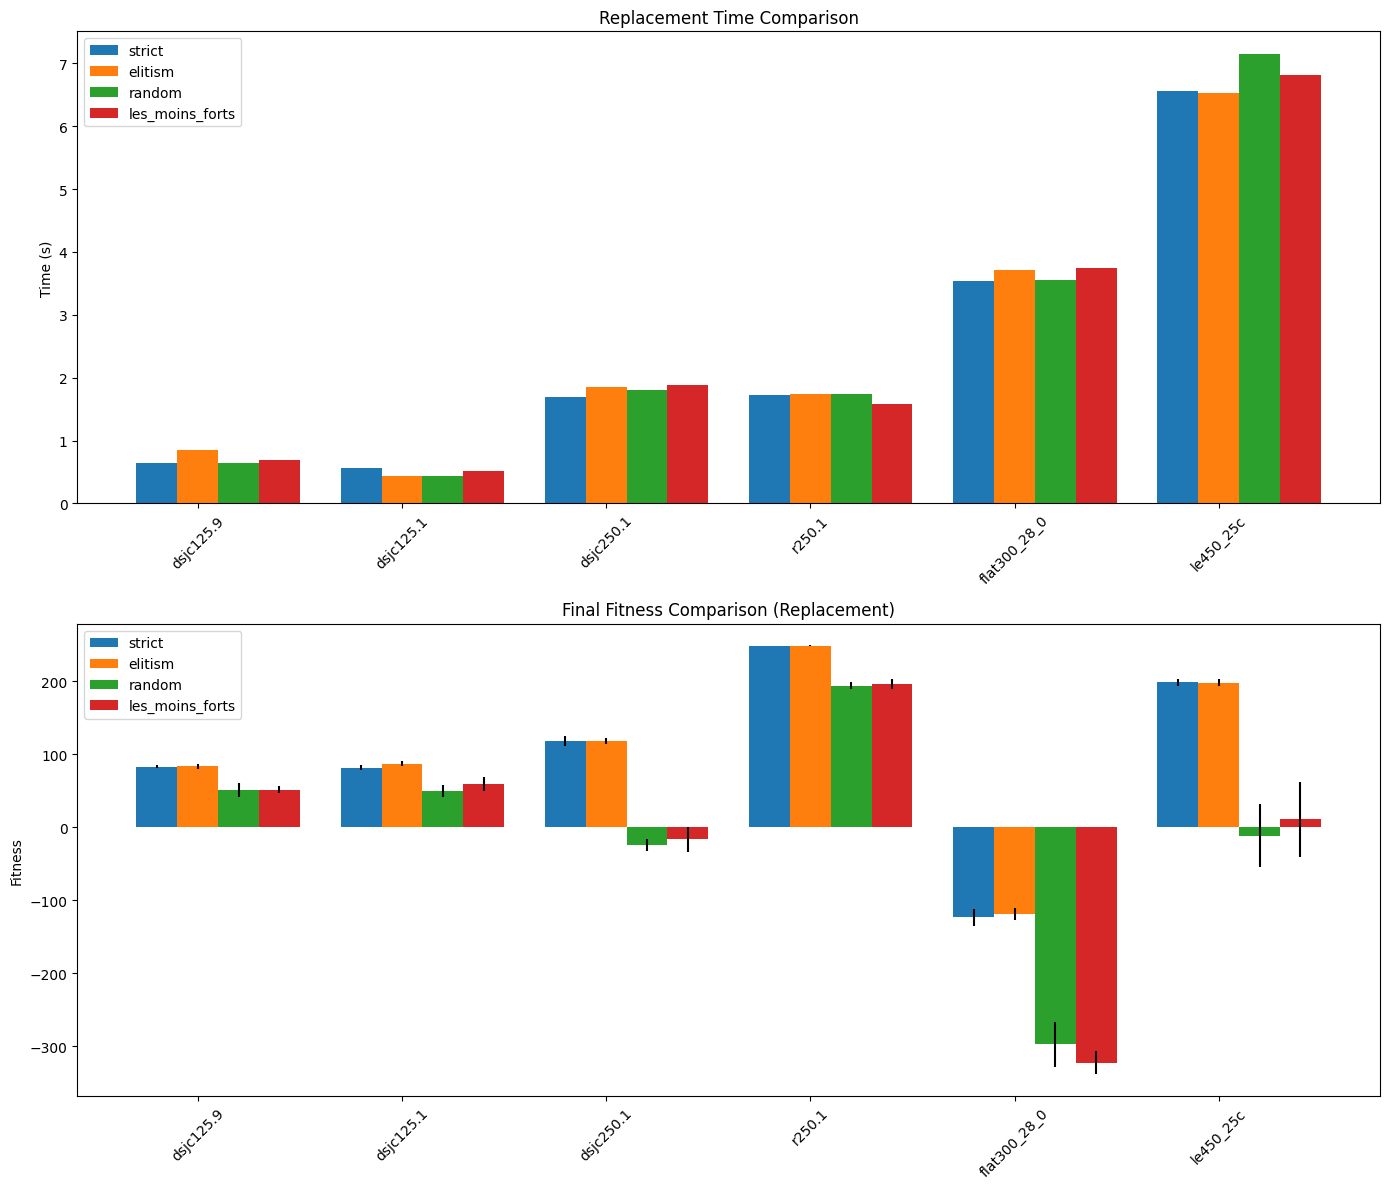

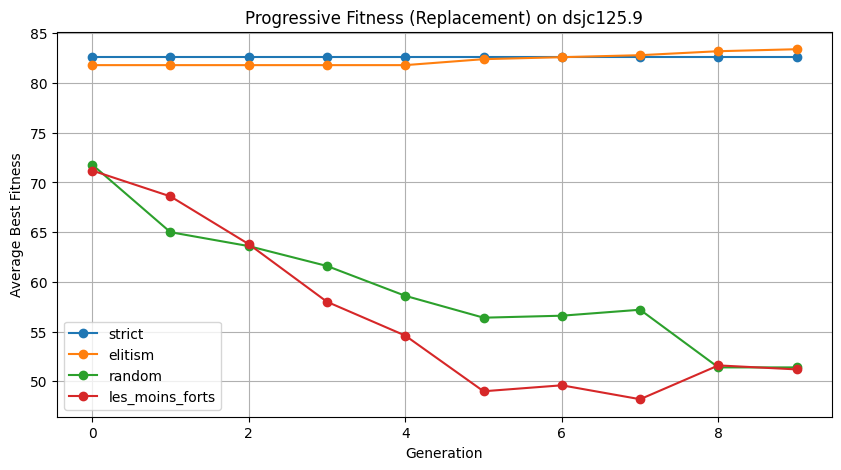

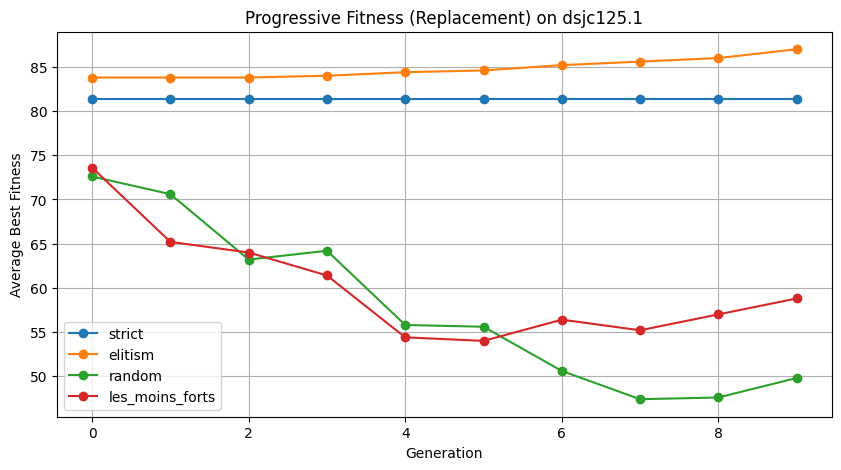

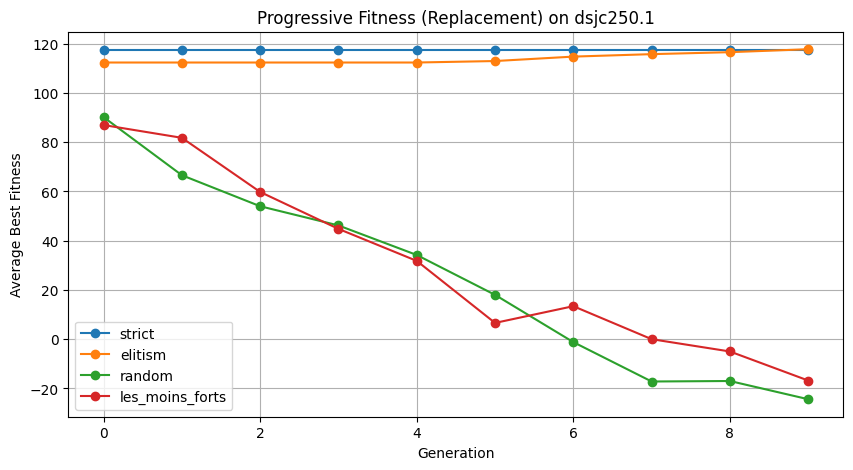

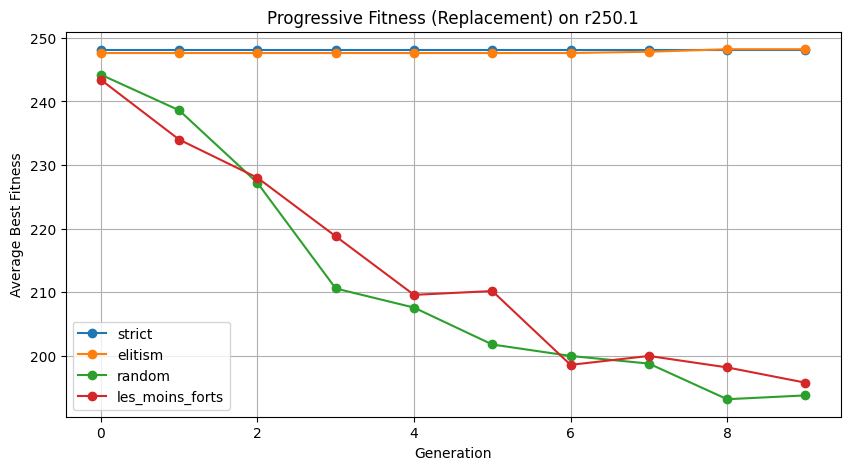

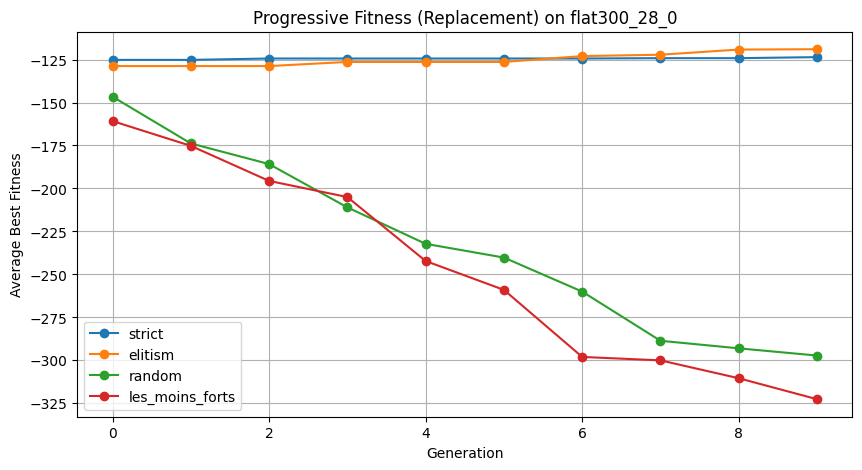

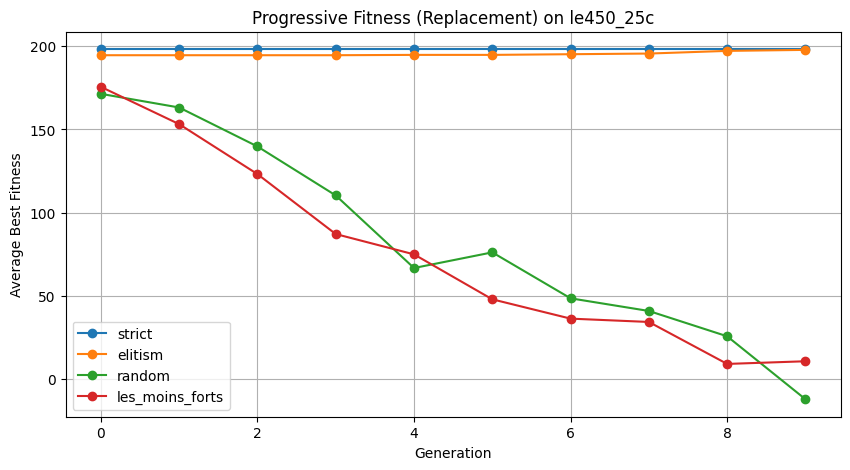

In [ ]:
# 1. Temps et Fitness finaux
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

x = np.arange(len(graphs_best))
width = 0.2

for i, method in enumerate(replacement_methods):
    times = [replacement_results[g][method]['avg_time'] for g in graphs_best]
    ax1.bar(x + i*width, times, width, label=method)

ax1.set_title('Replacement Time Comparison')
ax1.set_ylabel('Time (s)')
ax1.set_xticks(x + width)
ax1.set_xticklabels(graphs_best.keys(), rotation=45)
ax1.legend()

for i, method in enumerate(replacement_methods):
    fitness = [replacement_results[g][method]['avg_fitness'] for g in graphs_best]
    ax2.bar(x + i*width, fitness, width, label=method,
           yerr=[replacement_results[g][method]['std_fitness'] for g in graphs_best])

ax2.set_title('Final Fitness Comparison (Replacement)')
ax2.set_ylabel('Fitness')
ax2.set_xticks(x + width)
ax2.set_xticklabels(graphs_best.keys(), rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# 2. Fitness progressive
for graph in graphs_best:
    plt.figure(figsize=(10, 5))
    for method in replacement_methods:
        iterations = sorted(replacement_progressive_data[graph][method].keys())
        avg_fitness = [replacement_progressive_data[graph][method][it] for it in iterations]
        plt.plot(iterations, avg_fitness, label=method, marker='o')

    plt.title(f'Progressive Fitness (Replacement) on {graph}')
    plt.xlabel('Generation')
    plt.ylabel('Average Best Fitness')
    plt.legend()
    plt.grid(True)
    plt.show()

## Main AG

**La fonction genetic_algorithme** implémente ce cycle complet (population → sélection → croisement → mutation → remplacement) et ajuste le nombre de couleurs jusqu’à obtenir une solution valide.

**La fonction main** orchestre l’exécution de cet algorithme sur plusieurs graphes standards :

Elle charge les graphes,
Configure les paramètres pour chaque graphe,
Exécute l’algorithme génétique,
Et affiche un résumé des résultats : nombre de couleurs trouvées, conflits, temps d'exécution, et qualité de la solution.



Ainsi, ce programme permet d’expérimenter l’algorithme génétique pour évaluer son efficacité sur des graphes bien connus avec un objectif clair : obtenir une coloration valide en utilisant le moins de couleurs

In [ ]:
def genetic_algorithme(matrice, num_vertices, max_generations, crossover_rate,
                       mutation_rate, elitism_count, initial_colors, population_size):
    """
    Exécute l'algorithme génétique pour la coloration de graphe en augmentant
    le nombre de couleurs jusqu'à obtenir zéro conflit (coloration valide).
    """

    target_colors = initial_colors  # Nombre de couleurs de départ
    convergence_gen_total = 0

    # Générer la population initiale
    population = generate_population(population_size, matrice, num_vertices, target_colors)

    while True:
        best_solution = max(population, key=lambda c: c.fitness)
        best_fitness = best_solution.fitness
        no_improvement_count = 0
        convergence_gen = 0

        for generation in range(max_generations):
            parents = roulette_selection(population, max(population_size // 2, 2))
            new_generation = elitism_selection(population, min(elitism_count, len(population)))

            while len(new_generation) < population_size:
                if len(parents) < 2:
                    while len(parents) < 2:
                        coloring = [random.randint(1, target_colors) for _ in range(num_vertices)]
                        parents.append(Chromosome(coloring, matrice, num_vertices))
                parent1, parent2 = random.sample(parents, 2)

                if random.random() < crossover_rate:
                    child1, child2 = one_point_crossover(parent1, parent2, matrice, num_vertices)
                else:
                    child1, child2 = parent1, parent2

                child1 = mutate(child1, mutation_rate, matrice)
                child2 = mutate(child2, mutation_rate, matrice)

                new_generation.append(child1)
                if len(new_generation) < population_size:
                    new_generation.append(child2)

            population = remplacement_strict(population, new_generation, population_size, matrice)

            current_best = max(population, key=lambda c: c.fitness)
            if current_best.fitness > best_fitness:
                best_solution = current_best
                best_fitness = current_best.fitness
                no_improvement_count = 0
                convergence_gen = generation
            else:
                no_improvement_count += 1

            if calculate_conflicts(matrice, num_vertices, best_solution.coloring) == 0:
                convergence_gen_total += generation
                return best_solution, convergence_gen_total, best_fitness

            if no_improvement_count >= 50:
                break  # Augmenter le nombre de couleurs

        # Incrémenter le nombre de couleurs
        target_colors += 1
        convergence_gen_total += generation

        # Nouvelle population après augmentation du nombre de couleurs
        population = [
           Chromosome(
            inject_new_colors(best_solution.coloring, target_colors),
            matrice,
            num_vertices
           )
          for _ in range(population_size // 2)
        ] + generate_population(population_size // 2, matrice, num_vertices, target_colors)

In [ ]:
import random
import requests
import time
import statistics

def main():
    # Dictionnaire des graphes à tester avec leur nombre chromatique connu
    graphs_best = {
        "dsjc125.1": 5,
        "dsjc250.1": 8,
        "r250.1": 8,
    }

    # Paramètres spécifiques pour chaque graphe
    graph_parameters = {
        "dsjc125.1": {
            "population_size": 50,
            "max_generations": 70,
            "crossover_rate": 0.8,
            "mutation_rate": 0.1
        },
        "dsjc250.1": {
            "population_size": 45,
            "max_generations": 90,
            "crossover_rate": 0.8,
            "mutation_rate": 0.1
        },
        "r250.1": {
            "population_size": 50,
            "max_generations": 95,
            "crossover_rate": 0.85,
            "mutation_rate": 0.07
        }
    }

    results = {}
    time_ag=[]
    colors=[]

    for graph_name, best_color in graphs_best.items():

        # Charger les paramètres spécifiques pour ce graphe
        params = graph_parameters[graph_name]
        population_size = params["population_size"]
        max_generations = params["max_generations"]
        crossover_rate = params["crossover_rate"]
        mutation_rate = params["mutation_rate"]
        elitism_count = 5


        # Chargement du graphe
        try:
            start_time = time.time()
            matrice, number_nodes = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph_name}.col", is_url=True)

            if number_nodes == 0:
                print(f"Échec du chargement du graphe {graph_name}")
                continue

            # Initialisation de la population
            population = generate_population(population_size, matrice, number_nodes, best_color)

            # Vérification de la population initiale
            for i, chromo in enumerate(population):
                if chromo is None:
                    print(f"Warning: Chromosome {i} est None!")
                    # Remplacer le chromosome None par un valide
                    population[i] = Chromosome([random.randint(1, best_color) for _ in range(number_nodes)],
                                             matrice, number_nodes)

            # Exécution de l'algorithme génétique
            best_solution, convergence_gen, best_fitness = genetic_algorithme(
                matrice, number_nodes,
                max_generations, crossover_rate, mutation_rate,
                elitism_count, best_color,
                population_size
            )

            # Calcul du nombre de couleurs utilisées
            used_colors = len(set(best_solution.coloring))
            conflicts = calculate_conflicts(matrice, number_nodes, best_solution.coloring)
            colors.append(used_colors)

            # Temps d'exécution
            execution_time = time.time() - start_time
            time_ag.append(execution_time)


            # Stockage des résultats
            results[graph_name] = {
                "expected_colors": best_color,
                "used_colors": used_colors,
                "conflicts": conflicts,
                "fitness": best_solution.fitness,
                "convergence_gen": convergence_gen,
                "time": execution_time
            }


        except Exception as e:
            print(f"Erreur lors du traitement de {graph_name}: {e}")
            import traceback
            traceback.print_exc()

    return time_ag, colors, results

if __name__ == "__main__":
    time_ag, colors, results=main()
    # Résumé des résultats
    print("\n===== Résumé des résultats =====")
    for graph_name, result in results.items():
        success = "✓" if result["conflicts"] == 0 and result["used_colors"] <= result["expected_colors"] else "✗"
        print(f"{graph_name}: {success} {result['used_colors']}/{result['expected_colors']} couleurs,  {result['conflicts']} conflits,  {result['time']:.2f}s,  fitness: {result['fitness']}")


===== Résumé des résultats =====
dsjc125.1: ✗ 7/5 couleurs,  0 conflits,  3.23s,  fitness: 125
dsjc250.1: ✗ 12/8 couleurs,  0 conflits,  31.92s,  fitness: 250
r250.1: ✗ 9/8 couleurs,  0 conflits,  4.47s,  fitness: 250


Ce code permet de visualiser les performances de l'algorithme sur différents graphes. Le premier graphique compare le nombre de couleurs utilisées par l'algorithme avec le nombre de couleurs attendues (nombre chromatique) pour chaque graphe. Le second graphique montre le temps d'exécution de l'algorithme pour chaque graphe, ce qui permet d'évaluer son efficacité en termes de rapidité.

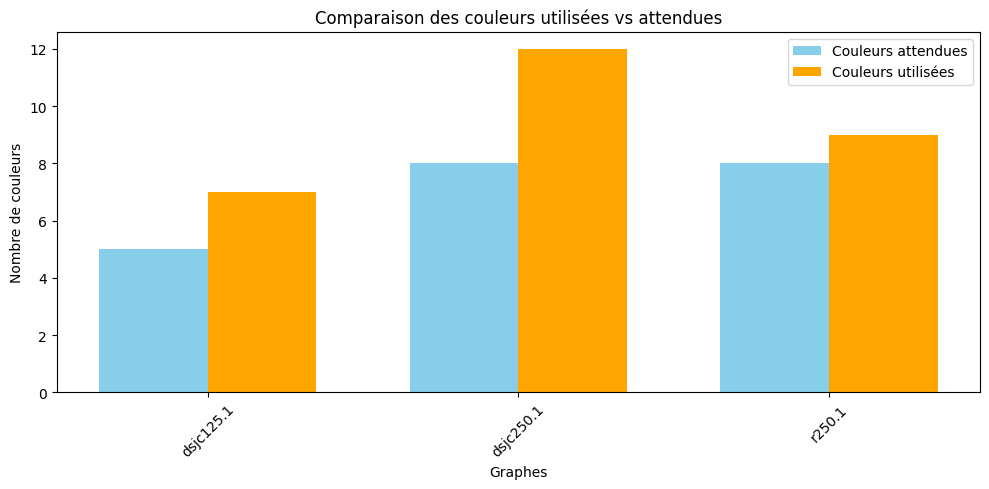

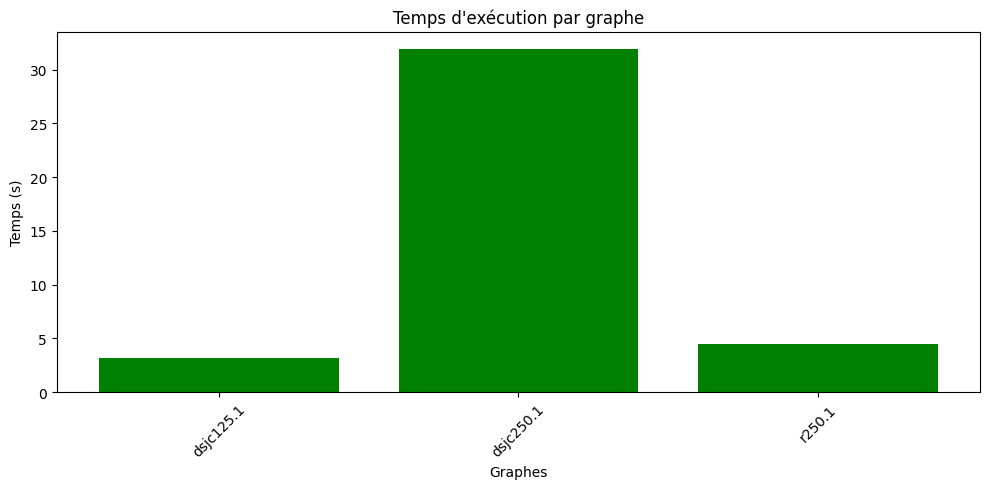

In [ ]:
graph_names = list(results.keys())
expected_colors = [results[g]["expected_colors"] for g in graph_names]
used_colors = [results[g]["used_colors"] for g in graph_names]
times = [results[g]["time"] for g in graph_names]

# Graph 1: Comparaison du nombre de couleurs utilisées vs attendues
plt.figure(figsize=(10, 5))
bar_width = 0.35
index = range(len(graph_names))

plt.bar(index, expected_colors, bar_width, label='Couleurs attendues', color='skyblue')
plt.bar([i + bar_width for i in index], used_colors, bar_width, label='Couleurs utilisées', color='orange')
plt.xlabel('Graphes')
plt.ylabel('Nombre de couleurs')
plt.title('Comparaison des couleurs utilisées vs attendues')
plt.xticks([i + bar_width / 2 for i in index], graph_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Graph 2: Temps d'exécution
plt.figure(figsize=(10, 5))
plt.bar(graph_names, times, color='green')
plt.xlabel('Graphes')
plt.ylabel('Temps (s)')
plt.title('Temps d\'exécution par graphe')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ACO

on commence par avoir dsatur qui va permettre d'obtenir une solution initiale rapide et déterminer un nb de couleurs de départ réaliste pour ACO.

P(c) = [tau(sommet,c)^alpha] * [eta(c)^beta] / Σ [tau(sommet,j)^alpha] * [eta(j)^beta]

In [ ]:
def valider_solution(matrice_triangulaire, solution):
    n = len(solution)
    for i in range(n):
        for j in range(i + 1):
            if matrice_triangulaire[i][j] == 1 and solution[i] == solution[j]:
                return False
    return True

In [ ]:
def est_adjacent(matrice, i, j):
    if i == j:
        return 0
    elif i > j:
        return matrice[i][j]
    else:
        return matrice[j][i]

In [ ]:
def calcul_degres(matrice_triangulaire, n):
    """
    Calcule le degré de chaque sommet pour une matrice triangulaire inférieure.
    """
    degres = [0] * n
    for i in range(n):
        for j in range(i + 1):
            if matrice_triangulaire[i][j] == 1:
                degres[i] += 1
                degres[j] += 1  # Car c'est symétrique
    return degres

## Optimisations notables dans notre implementation d'ACO

Cet algorithme implémente une métaheuristique par colonies de fourmis (ACO) pour résoudre le problème de coloration de graphe (GCP).

Il commence par estimer le nombre maximum de couleurs nécessaires (basé sur le degré maximal des sommets) et initialise une matrice de phéromones [sommet][couleur], où chaque valeur représente la désirabilité d'assigner une couleur à un sommet.

Les fourmis construisent ensuite des solutions de manière itérative : chaque fourmi colore les sommets dans un ordre prédéfini (décroissant du degré), en choisissant pour chaque sommet une couleur disponible parmi celles non utilisées par ses voisins.
Ce choix est guidé par une combinaison de phéromones (renforçant les choix historiquement efficaces) et d'une heuristique favorisant la réutilisation des couleurs déjà employées pour minimiser le nombre total de couleurs, pondérée par des paramètres α (importance des phéromones) et β (importance de l'heuristique).

Avec une probabilité q₀, la fourmi exploite la couleur la plus prometteuse, sinon elle explore aléatoirement pour essayer de nouvelles options.

Après chaque itération, les phéromones s'évaporent (taux ρ) pour éviter la stagnation, et les solutions valides déposent des phéromones proportionnellement à leur qualité (moins de couleurs utilisées = dépôt plus fort).

L'algorithme s'arrête lorsque la meilleure solution converge vers une estimation optimale ou après un nombre maximal d'itérations, renvoyant la meilleure coloration trouvée.


In [ ]:
def algo_principal_aco_gcp(matrice_adjacence, nb_sommets, nb_fourmis=10, nb_iterations=100,
                           alpha=1.0, beta=2.0, rho=0.1, q0=0.9, nb_couleurs_max=None):
    """
    Implémentation de l'algorithme ACO pour GCP.

    Paramètres:
    - matrice_adjacence: matrice d'adjacence du graphe
    - nb_sommets: nombre de sommets dans le graphe
    - nb_fourmis: nombre de fourmis utilisées à chaque itération
    - nb_iterations: nombre max d'itérations
    - alpha: importance des phéromones
    - beta: importance de l'heuristique
    - rho: taux d'évaporation des phéromones
    - q0: paramètre d'exploitation vs exploration
    - nb_couleurs_max: nombre maximum de couleurs (si None, sera estimé)

    Retourne:
    - solution: liste des couleurs attribuées à chaque sommet
    - temps d'exécution en secondes
    """
    debut = time.time()

    if nb_couleurs_max is None:
        degres = calcul_degres(matrice_adjacence, nb_sommets)
        degre_max = max(degres)
        nb_couleurs_max = min(degre_max + 1, nb_sommets)

    # Initialisation de la matrice de phéromones
    # Pour chaque sommet i et couleur j, tau[i][j] représente la désirabilité
    tau = np.ones((nb_sommets, nb_couleurs_max))
    meilleure_solution = None
    meilleur_nb_couleurs = float('inf')
    degres = calcul_degres(matrice_adjacence, nb_sommets)
    ordre_sommets = sorted(range(nb_sommets), key=lambda x: degres[x], reverse=True)
    for iteration in range(nb_iterations):
        solutions_fourmis = []
        for k in range(nb_fourmis):
            solution = [-1] * nb_sommets
            couleurs_utilisees = set()
            # xolorer les sommets dans l'ordre défini
            for sommet in ordre_sommets:
                #couleurs déjà utilisées par les voisins
                couleurs_voisins = set()
                for voisin in range(nb_sommets):
                    if est_adjacent(matrice_adjacence, sommet, voisin) == 1 and solution[voisin] != -1:
                        couleurs_voisins.add(solution[voisin])
                couleurs_disponibles = [c for c in range(nb_couleurs_max) if c not in couleurs_voisins]
                if not couleurs_disponibles:
                    solution = None
                    break

                #calcul des probabilités de sélection
                proba = np.zeros(len(couleurs_disponibles))
                for i, couleur in enumerate(couleurs_disponibles):
                    # heuristique: favoriser les couleurs déjà utilisées
                    eta = 2.0 if couleur in couleurs_utilisees else 1.0
                    proba[i] = (tau[sommet][couleur] ** alpha) * (eta ** beta)

                if np.sum(proba) > 0:
                    proba = proba / np.sum(proba)
                else:
                    proba = np.ones(len(couleurs_disponibles)) / len(couleurs_disponibles)


                if random.random() < q0:  # Exploitation
                    couleur_choisie = couleurs_disponibles[np.argmax(proba)]
                else:  # Exploration
                    couleur_choisie = np.random.choice(couleurs_disponibles, p=proba)

                solution[sommet] = couleur_choisie
                couleurs_utilisees.add(couleur_choisie)

            if solution:
                solutions_fourmis.append(solution)
        tau = (1 - rho) * tau  # Évaporation

        for solution in solutions_fourmis:
            nb_couleurs = len(set(solution))
            delta_tau = 1.0 / nb_couleurs
            for sommet, couleur in enumerate(solution):
                tau[sommet][couleur] += delta_tau
            if meilleure_solution is None or nb_couleurs < meilleur_nb_couleurs:
                meilleure_solution = solution.copy()
                meilleur_nb_couleurs = nb_couleurs
        if meilleur_nb_couleurs <= nb_couleurs_max:
            break

    fin = time.time()
    temps_execution = fin - debut

    return meilleure_solution, temps_execution

## Optimisations notables dans notre implementation d'ACO avec DSatur
une version améliorée qui intègre l'algorithme DSATUR (Degree of Saturation) avec ACO (inspiree d'un article scientifique de madame bessedik qui est cite juste en dessous dans la section ressources)

On utilise une matrice de phéromones tau[sommet1][sommet2] entre paires de sommets non adjacents. Les phéromones sont nulles entre sommets adjacents (logique, car ils ne peuvent pas partager la même couleur). Cette approche favorise le regroupement de sommets non adjacents dans la même classe de couleur.

Les phéromones guident les fourmis à regrouper des sommets non adjacents dans la même classe de couleur, au lieu de guider vers le choix d'une couleur spécifique. Cette approche ne nécessite pas de connaître à l'avance le nombre exact de couleurs nécessaires, elle cherche plutôt à construire des ensembles indépendants de sommets.

Le premier algorithme utilise un ordre statique basé sur le degré des sommets, l'ordre est déterminé une fois au début et ne change pas pendant l'exécution mais dans cet algorithme on implémente la stratégie dynamique DSATUR qui sélectionne le prochain sommet à colorier selon : le degré de saturation (nombre de couleurs différentes déjà attribuées aux voisins) et en cas d'égalité, le degré du sommet.

L'ordre est recalculé après chaque coloration de sommet, ce qui est généralement plus efficace, mais ajoute de la complexite en termes de temps d'execution

### Implications des différences et pourquoi cet approche donne des resultats plus proches de l'optimal que la premiere
DSATUR est une des meilleures heuristiques pour la coloration de graphe

La représentation des phéromones favorise la formation de classes de couleur stables

L'ordre dynamique de traitement des sommets s'adapte mieux à la structure du graphe

In [ ]:
def algo_principal_aco_gcp_dsat(matrice_adjacence, nb_sommets, nb_fourmis=10, nb_iterations=100,
                           alpha=1.0, beta=2.0, rho=0.1, q0=0.9, nb_couleurs_max=None):
    """
    Implémentation améliorée de l'algorithme ACO pour GCP avec DSATUR.

    Paramètres:
    - matrice_adjacence: matrice d'adjacence du graphe
    - nb_sommets: nombre de sommets dans le graphe
    - nb_fourmis: nombre de fourmis utilisées à chaque itération
    - nb_iterations: nombre max d'itérations
    - alpha: importance des phéromones
    - beta: importance de l'heuristique
    - rho: taux d'évaporation des phéromones
    - q0: paramètre d'exploitation vs exploration
    - nb_couleurs_max: nombre maximum de couleurs (si None, sera estimé)

    Retourne:
    - solution: liste des couleurs attribuées à chaque sommet
    - temps d'exécution en secondes
    """
    debut = time.time()
    if nb_couleurs_max is None:
        degres = calcul_degres(matrice_adjacence, nb_sommets)
        degre_max = max(degres)
        nb_couleurs_max = min(degre_max + 1, nb_sommets)
    tau = np.ones((nb_sommets, nb_sommets))
    for i in range(nb_sommets):
        for j in range(i+1, nb_sommets):
            if est_adjacent(matrice_adjacence, i, j) == 1:  # Si les sommets sont adjacents
                tau[i][j] = tau[j][i] = 0.0  # Pas de phéromone
    meilleure_solution = None
    meilleur_nb_couleurs = float('inf')
    degres = calcul_degres(matrice_adjacence, nb_sommets)
    for iteration in range(nb_iterations):
        solutions_fourmis = []
        for k in range(nb_fourmis):
            solution = [-1] * nb_sommets
            couleurs_utilisees = set()
            while -1 in solution:
                dsat = np.zeros(nb_sommets, dtype=int)
                for v in range(nb_sommets):
                    if solution[v] == -1:
                        couleurs_voisins = set()
                        for u in range(nb_sommets):
                            if  est_adjacent(matrice_adjacence, v, u) == 1 and solution[u] != -1:
                                couleurs_voisins.add(solution[u])
                        dsat[v] = len(couleurs_voisins)
                sommets_non_colores = [v for v in range(nb_sommets) if solution[v] == -1]
                sommet = max(sommets_non_colores, key=lambda x: (dsat[x], degres[x]))
                couleurs_voisins = set()
                for u in range(nb_sommets):
                    if est_adjacent(matrice_adjacence, sommet, u) == 1 and solution[u] != -1:
                        couleurs_voisins.add(solution[u])
                couleurs_disponibles = [c for c in range(nb_couleurs_max) if c not in couleurs_voisins]
                if not couleurs_disponibles:
                    solution = None
                    break
                proba = np.zeros(len(couleurs_disponibles))
                for i, couleur in enumerate(couleurs_disponibles):
                    # Heuristique: favoriser les couleurs les moins utilisées (comme DSATUR)
                    eta = 1.0 / (1 + sum(1 for v in range(nb_sommets) if solution[v] == couleur))
                    pheromone_sum = sum(
                        tau[sommet][u]
                        for u in range(nb_sommets)
                        if solution[u] == couleur and est_adjacent(matrice_adjacence, sommet, u) == 0
                    )

                    proba[i] = (pheromone_sum ** alpha) * (eta ** beta)
                if np.sum(proba) > 0:
                    proba = proba / np.sum(proba)
                else:
                    proba = np.ones(len(couleurs_disponibles)) / len(couleurs_disponibles)
                if random.random() < q0:  # Exploitation
                    couleur_choisie = couleurs_disponibles[np.argmax(proba)]
                else:  # Exploration
                    couleur_choisie = np.random.choice(couleurs_disponibles, p=proba)

                solution[sommet] = couleur_choisie
                couleurs_utilisees.add(couleur_choisie)

            if solution:
                solutions_fourmis.append(solution)

        tau = (1 - rho) * tau  # Évaporation

        for solution in solutions_fourmis:
            nb_couleurs = len(set(solution))
            delta_tau = 1.0 / nb_couleurs
            for u in range(nb_sommets):
                for v in range(u+1, nb_sommets):
                    if est_adjacent(matrice_adjacence, u, v) == 0 and solution[u] == solution[v]:
                        tau[u][v] += delta_tau
                        tau[v][u] += delta_tau
            if meilleure_solution is None or nb_couleurs < meilleur_nb_couleurs:
                meilleure_solution = solution.copy()
                meilleur_nb_couleurs = nb_couleurs
        if meilleur_nb_couleurs <= nb_couleurs_max:
            break

    fin = time.time()
    temps_execution = fin - debut
    return meilleure_solution, temps_execution

## Test

In [ ]:
graphs_bench = {
    "dsjc125.9": 44,
    "dsjc125.1": 5,
    "dsjc250.1": 8,
    "r250.1": 8,
    "flat300_28_0": 28,
    "le450_25c": 25
}

for graph, borne_inf in graphs_bench.items():
    print(f"\n=== Résultats pour {graph} ===")
    matx, n = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col", is_url=True)

    # Appel de l'algorithme ACO
    solution, exec_time = algo_principal_aco_gcp_dsat(matx, n, nb_fourmis=20, nb_iterations=200, alpha=1.0, beta=2.0, rho=0.1, q0=0.9)

    if solution and valider_solution(matx, solution):
        nb_couleurs = len(set(solution))
        print(f"Meilleure solution: {nb_couleurs} couleurs")
        print(f"Borne inférieure: {borne_inf} couleurs")
        print(f"Écart: {nb_couleurs - borne_inf} couleurs")
        print(f"Temps d'exécution: {exec_time:.2f} secondes")
    else:
        print("Aucune solution valide trouvée.")


=== Résultats pour dsjc125.9 ===
Meilleure solution: 51 couleurs
Borne inférieure: 44 couleurs
Écart: 7 couleurs
Temps d'exécution: 5.62 secondes

=== Résultats pour dsjc125.1 ===
Meilleure solution: 6 couleurs
Borne inférieure: 5 couleurs
Écart: 1 couleurs
Temps d'exécution: 3.08 secondes

=== Résultats pour dsjc250.1 ===
Meilleure solution: 10 couleurs
Borne inférieure: 8 couleurs
Écart: 2 couleurs
Temps d'exécution: 24.08 secondes

=== Résultats pour r250.1 ===
Meilleure solution: 8 couleurs
Borne inférieure: 8 couleurs
Écart: 0 couleurs
Temps d'exécution: 21.46 secondes

=== Résultats pour flat300_28_0 ===
Meilleure solution: 39 couleurs
Borne inférieure: 28 couleurs
Écart: 11 couleurs
Temps d'exécution: 64.25 secondes

=== Résultats pour le450_25c ===
Meilleure solution: 28 couleurs
Borne inférieure: 25 couleurs
Écart: 3 couleurs
Temps d'exécution: 189.92 secondes


In [ ]:
graphs_bench = {
    "dsjc125.9": 44,
    "dsjc125.1": 5,
    "dsjc250.1": 8,
    "r250.1": 8,
    "flat300_28_0": 28,
    "le450_25c": 25
}

for graph, borne_inf in graphs_bench.items():
    print(f"\n=== Résultats pour {graph} ===")
    matx, n = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col", is_url=True)

    # Appel de l'algorithme ACO
    solution, exec_time = algo_principal_aco_gcp(matx, n, nb_fourmis=20, nb_iterations=200,
                                                alpha=1.0, beta=2.0, rho=0.1, q0=0.9)

    if solution and valider_solution(matx, solution):
        nb_couleurs = len(set(solution))
        print(f"Meilleure solution: {nb_couleurs} couleurs")
        print(f"Borne inférieure: {borne_inf} couleurs")
        print(f"Écart: {nb_couleurs - borne_inf} couleurs")
        print(f"Temps d'exécution: {exec_time:.2f} secondes")
    else:
        print("Aucune solution valide trouvée.")


=== Résultats pour dsjc125.9 ===
Meilleure solution: 55 couleurs
Borne inférieure: 44 couleurs
Écart: 11 couleurs
Temps d'exécution: 0.34 secondes

=== Résultats pour dsjc125.1 ===
Meilleure solution: 8 couleurs
Borne inférieure: 5 couleurs
Écart: 3 couleurs
Temps d'exécution: 0.14 secondes

=== Résultats pour dsjc250.1 ===
Meilleure solution: 16 couleurs
Borne inférieure: 8 couleurs
Écart: 8 couleurs
Temps d'exécution: 0.54 secondes

=== Résultats pour r250.1 ===
Meilleure solution: 10 couleurs
Borne inférieure: 8 couleurs
Écart: 2 couleurs
Temps d'exécution: 0.36 secondes

=== Résultats pour flat300_28_0 ===
Meilleure solution: 47 couleurs
Borne inférieure: 28 couleurs
Écart: 19 couleurs
Temps d'exécution: 1.44 secondes

=== Résultats pour le450_25c ===
Meilleure solution: 41 couleurs
Borne inférieure: 25 couleurs
Écart: 16 couleurs
Temps d'exécution: 2.97 secondes


# Comparaison entre le temps d'éxecution et le nombre de couleurs sur différentes benchmarks pour les méthodes "AG", "ACO" et "ACO-Dsatur"







In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def afficher_graphes(execution_times, color_counts, graph_names, titre_suffixe=""):
    # Temps d'exécution
    plt.figure(figsize=(10, 5))
    for algo, times in execution_times.items():
        plt.plot(graph_names, times, marker='o', label=algo)

    plt.title(f"Temps d'exécution (secondes) {titre_suffixe}")
    plt.xlabel("Graphe")
    plt.ylabel("Temps (s)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    # Nombre de couleurs utilisées
    plt.figure(figsize=(10, 5))
    algorithms = list(color_counts.keys())
    x = np.arange(len(graph_names))
    bar_width = 0.25

    for i, algo in enumerate(algorithms):
        offset = (i - (len(algorithms) - 1) / 2) * bar_width
        plt.bar(x + offset, color_counts[algo], width=bar_width, label=algo)

    plt.title(f"Nombre de couleurs utilisées {titre_suffixe}")
    plt.xlabel("Graphe")
    plt.ylabel("Nombre de couleurs")
    plt.xticks(x, graph_names, rotation=45)
    plt.legend()
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


In [ ]:
graphs_bench = {
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "r250.1": "8"
}

execution_times = {
    "aco": [],
    "aco_dsat": [],
    "genetique": []
}
color_counts = {
    "aco": [],
    "aco_dsat": [],
    "genetique": []
}
graph_names = []

for graph, best in graphs_bench.items():
    print("\n=== GRAPH:", graph, "===")
    graph_names.append(graph)

    matx, n = lire_graphe_triangulaire(
        f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col",
        is_url=True
    )
    nb_couleurs = int(best.split("/")[0]) + 5

    # --- ACO simple
    sol_aco, time_aco = algo_principal_aco_gcp(
        matrice_adjacence=matx,
        nb_sommets=n,
        nb_fourmis=20,
        nb_iterations=200,
        alpha=1.0,
        beta=2.0,
        rho=0.1,
        q0=0.9,
        nb_couleurs_max=nb_couleurs
    )
    chroma_aco = len(set(sol_aco))
    execution_times["aco"].append(time_aco)
    color_counts["aco"].append(chroma_aco)

    # --- ACO avec DSATUR
    sol_aco_dsat, time_aco_dsat = algo_principal_aco_gcp_dsat(
        matrice_adjacence=matx,
        nb_sommets=n,
        nb_fourmis=20,
        nb_iterations=200,
        alpha=1.0,
        beta=2.0,
        rho=0.1,
        q0=0.9,
        nb_couleurs_max=nb_couleurs
    )
    chroma_aco_dsat = len(set(sol_aco_dsat))
    execution_times["aco_dsat"].append(time_aco_dsat)
    color_counts["aco_dsat"].append(chroma_aco_dsat)

time_ag, chroma_genetique = main()
#chroma_genetique = len(set(sol_genetique.coloring))
execution_times["genetique"]=time_ag  # Attention: il faudrait chronométrer le temps ici
color_counts["genetique"]=chroma_genetique




=== GRAPH: dsjc125.1 ===

=== GRAPH: dsjc250.1 ===

=== GRAPH: r250.1 ===
Graphe chargé: 125 sommets
Graphe chargé: 250 sommets
Graphe chargé: 250 sommets

===== Résumé des résultats =====
dsjc125.1: ✗ 8/5 couleurs,  0 conflits,  5.26s,  fitness: 125
dsjc250.1: ✗ 12/8 couleurs,  0 conflits,  26.23s,  fitness: 250
r250.1: ✗ 9/8 couleurs,  0 conflits,  3.99s,  fitness: 250


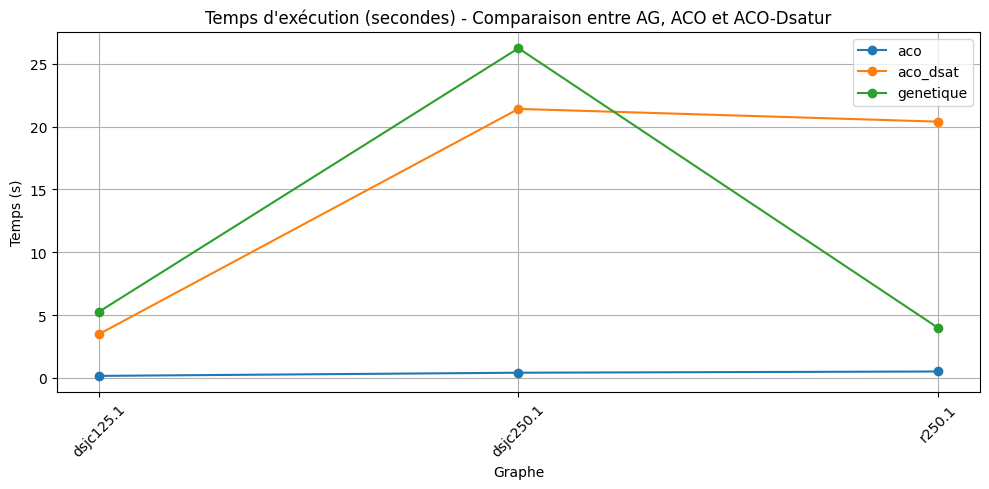

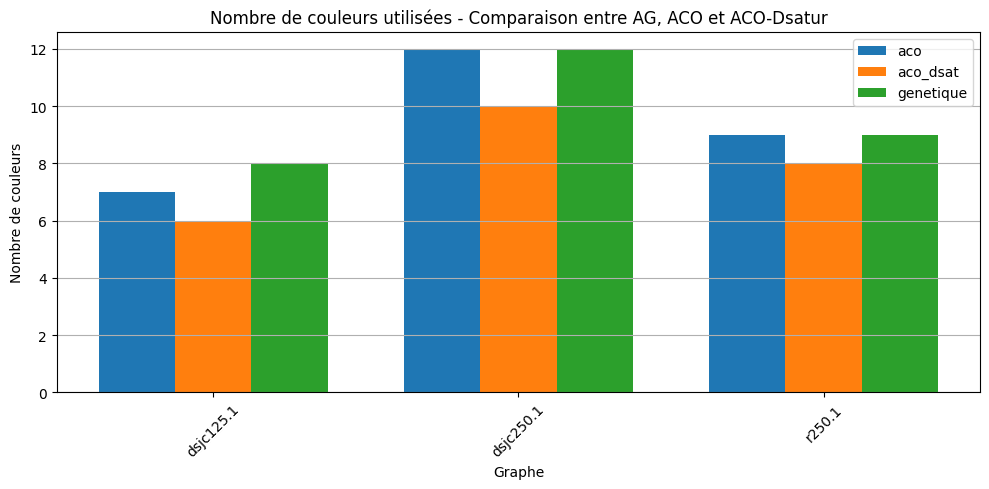

In [ ]:
afficher_graphes(execution_times, color_counts, graph_names, titre_suffixe="- Comparaison entre AG, ACO et ACO-Dsatur")


##Interprétation

**Temps d'exécution :**

ACO-Dsatur et ACO sont plus rapide car il utilise une approche déterministe guidée par des phéromones et une heuristique . Les phéromones mettent à jour directement les probabilités de choix des couleurs, réduisant les itérations nécessaires pour converger. En revanche, l'AG dépend de la sélection, du croisement et de la mutation de toute une population , ce qui implique un coût computationnel élevé (ex. calcul de fitness, gestion de la population, ajustement dynamique du nombre de couleurs).
mais L'ACO-Dsature est moin rapide que l'ACO car L'ordre est recalculé après chaque coloration de sommet, ce qui est généralement plus efficace, mais ajoute de la complexite en termes de temps d'execution

**Nombre de couleurs utilisées :**

ACO-Dsatur utilise moins de couleurs grâce à l'heuristique DSATUR, qui priorise les sommets les plus contraints (maximisant l'efficacité de la coloration). Les phéromones renforcent les choix qui minimisent les conflits.
L'AG utilise plus de couleurs car la mutation aléatoire et le croisement peuvent générer des configurations sous-optimales, surtout si la population n'est pas bien paramétrée (ex. taux de mutation trop élevé ou population trop petite).

# Comparaison entre le temps d'éxecution et le nombre de couleurs sur différentes benchmarks pour les méthodes "ACO-Dsatur" et "RS adaptatif"


In [ ]:
#meilleure exploration(diversification) au début: à cause d'une température élevée maintenue plus longtemps si les solutions stagnent
# meilleure exploitation bers la fin: le voisinage se resserre autour des bonnes zones (intensification locale)
# et parceque il est dynamique: il s’autorégule, donc moins besoin de fine-tune la température initiale et la décroissance
# il évolue selon ce qui'il observe sur lq qualité des solutions
# la température ne diminue pas de manière fixe mais s'adapte selon le progrés // qualité des solutions
# la stratégie de génération de voisinage peut aussi changer dynamiquement

def recuit_simule_adaptatif(
    adj_matrix, num_vertices, chromatic_number,
    T_initial=1000, T_min=0.01,
    max_iter=10000, stagnation_threshold=100,
    alpha=0.95, max_color_increase=20
):
    """
    Recuit Simulé Adaptatif avec auto-correction si des conflits persistent après la phase principale.
    Relance automatiquement avec plus de couleurs jusqu'à obtenir une solution valide (conflict-free).
    """

    start_total = time.time()

    for extra_colors in range(max_color_increase + 1):
        k = chromatic_number + extra_colors

        # Initialisation
        current_solution = initialize_solution(num_vertices, k)
        current_cost = calculate_conflicts(adj_matrix, num_vertices, current_solution)

        best_solution = current_solution.copy()
        best_cost = current_cost

        T = T_initial
        no_improvement = 0

        for iteration in range(max_iter):
            # Arrêt immédiat si solution valide
            if best_cost == 0:
                end_total = time.time()
                return best_solution, best_cost, end_total - start_total

            # Génération d’un voisin
            neighbor = generate_neighbor(current_solution, k)
            neighbor_cost = calculate_conflicts(adj_matrix, num_vertices, neighbor)

            # Acceptation selon critère
            delta = neighbor_cost - current_cost
            if delta < 0 or random.random() < math.exp(-delta / T):
                current_solution = neighbor
                current_cost = neighbor_cost

                if current_cost < best_cost:
                    best_solution = current_solution.copy()
                    best_cost = current_cost
                    no_improvement = 0
                else:
                    no_improvement += 1
            else:
                no_improvement += 1

            # Refroidissement adaptatif
            if no_improvement >= stagnation_threshold:
                T *= alpha  # accélère le refroidissement si stagnation
                no_improvement = 0
            else:
                T *= 0.99  # refroidissement normal

            # Température minimale atteinte
            if T < T_min:
                break

        # Si toujours des conflits, essayer avec plus de couleurs
        print(f"[INFO] Conflits restants ({best_cost}) → nouvelle tentative avec {k+1} couleurs.")

    # Retour final si on atteint max_color_increase et qu'on n'a toujours pas 0 conflit
    end_total = time.time()
    return best_solution, best_cost, end_total - start_total

In [ ]:
graphs_bench = {
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "r250.1": "8"
}

execution_times2 = {
    "aco_dsatur": [],
    "recuit_adaptatif": []
}
color_counts2 = {
    "aco_dsatur": [],
    "recuit_adaptatif": []
}
graph_names2 = []

for graph, best in graphs_bench.items():
    print("\n=== GRAPH:", graph, "===")
    graph_names2.append(graph)

    matx, n = lire_graphe_triangulaire(
        f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col",
        is_url=True
    )
    nb_couleurs = int(best.split("/")[0]) + 5

    # --- ACO avec DSATUR
    sol_aco_dsatur, time_aco_dsatur = algo_principal_aco_gcp_dsat(
        matrice_adjacence=matx,
        nb_sommets=n,
        nb_fourmis=10,
        nb_iterations=100,
        alpha=1.0,
        beta=2.0,
        rho=0.1,
        q0=0.9,
        nb_couleurs_max=nb_couleurs
    )
    chroma_aco_dsatur = len(set(sol_aco_dsatur))
    execution_times2["aco_dsatur"].append(time_aco_dsatur)
    color_counts2["aco_dsatur"].append(chroma_aco_dsatur)

    # --- Récuit Simulé Adaptatif
    sol_rsa, conflits_rsa, time_rsa = recuit_simule_adaptatif(
        adj_matrix=matx,
        num_vertices=n,
        chromatic_number=nb_couleurs,
        T_initial=100,
        alpha=0.9
    )
    chroma_rsa = len(set(sol_rsa))
    execution_times2["recuit_adaptatif"].append(time_rsa)
    color_counts2["recuit_adaptatif"].append(chroma_rsa)



=== GRAPH: dsjc125.1 ===
[INFO] Conflits restants (3) → nouvelle tentative avec 11 couleurs.
[INFO] Conflits restants (3) → nouvelle tentative avec 12 couleurs.
[INFO] Conflits restants (5) → nouvelle tentative avec 13 couleurs.
[INFO] Conflits restants (3) → nouvelle tentative avec 14 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 15 couleurs.
[INFO] Conflits restants (5) → nouvelle tentative avec 16 couleurs.
[INFO] Conflits restants (4) → nouvelle tentative avec 17 couleurs.

=== GRAPH: dsjc250.1 ===
[INFO] Conflits restants (87) → nouvelle tentative avec 14 couleurs.
[INFO] Conflits restants (69) → nouvelle tentative avec 15 couleurs.
[INFO] Conflits restants (69) → nouvelle tentative avec 16 couleurs.
[INFO] Conflits restants (70) → nouvelle tentative avec 17 couleurs.
[INFO] Conflits restants (53) → nouvelle tentative avec 18 couleurs.
[INFO] Conflits restants (40) → nouvelle tentative avec 19 couleurs.
[INFO] Conflits restants (37) → nouvelle tentative avec 20

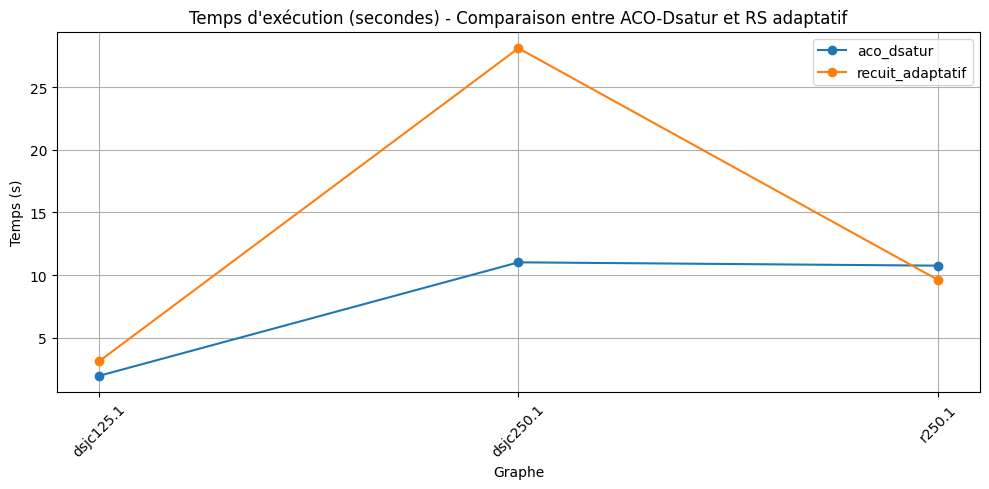

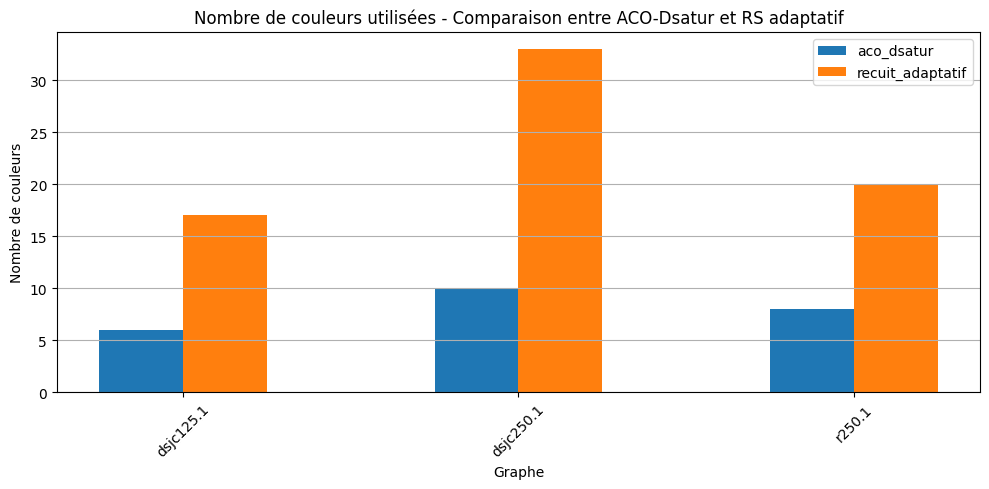

In [ ]:
afficher_graphes(execution_times2, color_counts2, graph_names2, titre_suffixe="- Comparaison entre ACO-Dsatur et RS adaptatif")

##Interprétation

**Temps d'exécution :**

RS est généralement plus rapide par itération car il modifie une seule solution à la fois. Toutefois, il peut nécessiter de nombreuses itérations pour échapper aux optima locaux.
ACO-Dsatur, bien que plus coûteux en calcul (car plusieurs fourmis construisent des solutions), converge plus rapidement vers de bonnes zones de l’espace de recherche grâce à la mémoire collective apportée par les phéromones.

**Nombre de couleurs :**

ACO-Dsatur est plus efficace car il combine :

DSATUR : Sélection des sommets les plus contraints pour éviter les conflits.
Phéromones : Qui minimisent les conflits.

Le RS utilise plus de couleurs car sa stratégie de voisinage (mutation locale) ne garantit pas une exploration optimale des structures du graphe. La température adaptative aide mais ne compense pas le manque de mémoire globale (contrairement aux phéromones).


# Comparaison entre le temps d'éxecution et le nombre de couleurs sur différentes benchmarks pour les méthodes "ACO-Dsatur" et "Dsatur"

In [ ]:
def dsatur(matrice_triangulaire):
  start = time.time()
  n = len(matrice_triangulaire)
  voisins = {i: get_neighbors(i, matrice_triangulaire,n) for i in range (n)}
  coloring = [None]*n # affectation initial
  ensemble_saturation = [set() for _ in range(n)] #initialisation des ensembles de saturation de chaque noeud
  degre = [len(voisins[i]) for i in range(n)] # Use a list, not a set
  # tantque on n'a pas fini de colorier otus les noeuds
  while any(color is None for color in coloring): # Loop until all nodes are colored
    non_colories = [i for i in range(n) if coloring[i] is None]
    if not non_colories:
          break
    chosen = max(non_colories, key=lambda x: (len(ensemble_saturation[x]), degre[x]))
    used_colors = {coloring[v] for v in voisins[chosen] if coloring[v] is not None}
    color = 0
    while color in used_colors:
      color += 1
    coloring[chosen] = color
    for v in voisins[chosen]:
        if coloring[v] is None:
            ensemble_saturation[v].add(color)
  chromatic_number = max(coloring) + 1 if coloring else 0
  temps = time.time() - start
  return chromatic_number, coloring, temps

In [ ]:
graphs_bench = {
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "r250.1": "8"
}

execution_times3 = {
    "dsatur": [],
    "aco_dsatur": []
}
color_counts3 = {
    "dsatur": [],
    "aco_dsatur": []
}
graph_names3 = []

for graph, best in graphs_bench.items():
    print("\n=== GRAPH:", graph, "===")
    graph_names3.append(graph)

    matx, n = lire_graphe_triangulaire(
        f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col",
        is_url=True
    )
    nb_couleurs = int(best) + 5

    # --- DSATUR
    chroma_dsatur, sol_dsatur, time_dsatur = dsatur(matx)
    execution_times3["dsatur"].append(time_dsatur)
    color_counts3["dsatur"].append(chroma_dsatur)

    # --- ACO avec DSATUR
    sol_aco_dsatur, time_aco_dsatur = algo_principal_aco_gcp_dsat(
        matrice_adjacence=matx,
        nb_sommets=n,
        nb_fourmis=10,
        nb_iterations=100,
        alpha=1.0,
        beta=2.0,
        rho=0.1,
        q0=0.9,
        nb_couleurs_max=nb_couleurs
    )
    chroma_aco_dsatur = len(set(sol_aco_dsatur))
    execution_times3["aco_dsatur"].append(time_aco_dsatur)
    color_counts3["aco_dsatur"].append(chroma_aco_dsatur)

    # Affichage récapitulatif
    print(f"  DSATUR: {chroma_dsatur} colors in {time_dsatur:.4f} seconds")
    print(f"  ACO+DSATUR: {chroma_aco_dsatur} colors in {time_aco_dsatur:.4f} seconds")



=== GRAPH: dsjc125.1 ===
  DSATUR: 6 colors in 0.0035 seconds
  ACO+DSATUR: 6 colors in 1.5746 seconds

=== GRAPH: dsjc250.1 ===
  DSATUR: 10 colors in 0.0120 seconds
  ACO+DSATUR: 10 colors in 10.9886 seconds

=== GRAPH: r250.1 ===
  DSATUR: 8 colors in 0.0106 seconds
  ACO+DSATUR: 8 colors in 10.7914 seconds


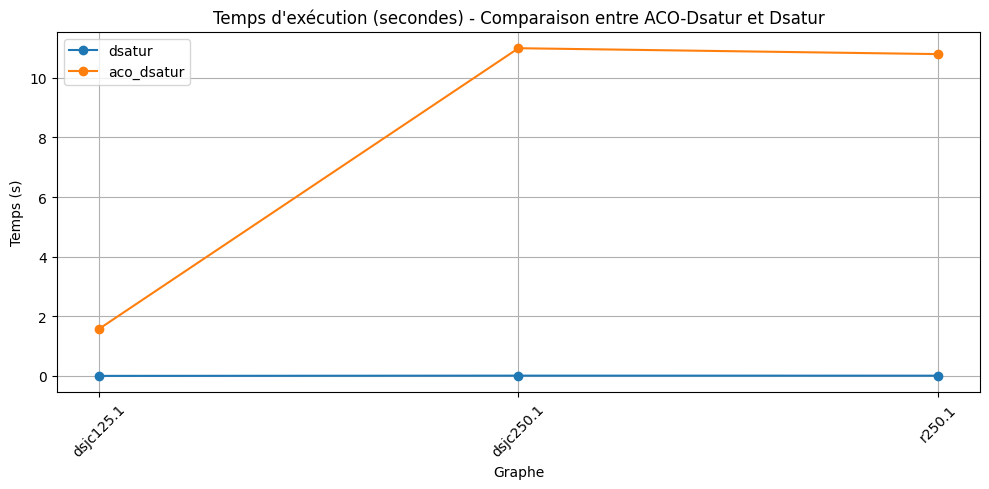

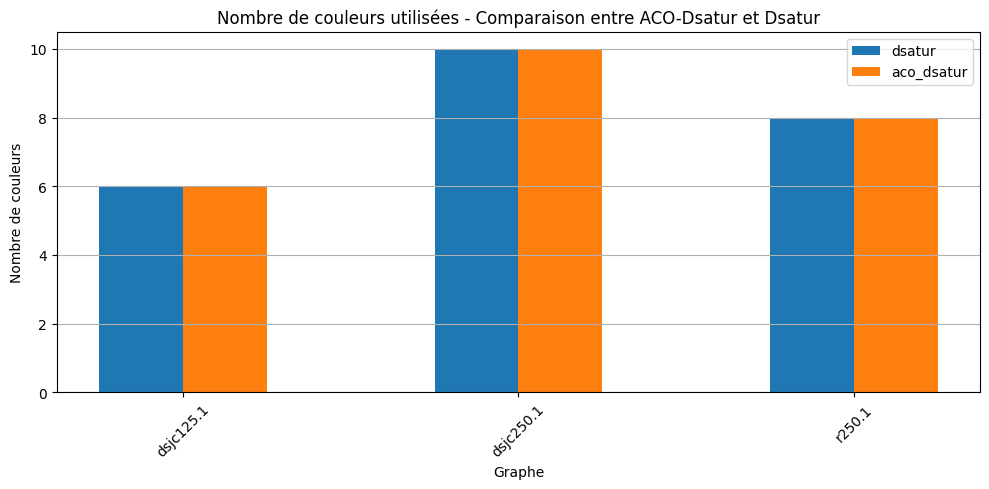

In [ ]:
afficher_graphes(execution_times3, color_counts3, graph_names3, titre_suffixe="- Comparaison entre ACO-Dsatur et Dsatur")

##Interpretation

**Temps d'exécution :**

DSATUR est extrêmement rapide car c'est un algorithme glouton déterministe :
Il sélectionne le sommet avec le plus haut degré de saturation à chaque étape.
Il attribue la première couleur disponible sans backtracking ni itérations multiples.
ACO-Dsatur est plus lent car il intègre des mécanismes stochastiques (choix probabilistes basés sur les phéromones) et des itérations multiples pour affiner la solution.

**Nombre de couleurs :**

DSATUR est souvent très efficace sur des graphes bien structurés. ACO-Dsatur peut donner des résultats moins bons au début, mais améliorer avec le temps et surpasser DSATUR sur des graphes complexes en raison de la diversification introduite par les fourmis.


#Conclusion


**En termes de temps :**

Les méthodes déterministes et gloutonnes (DSATUR) dominent grâce à leur simplicité algorithmique, tandis que les approches stochastiques (ACO, AG, RS) souffrent de coûts liés à l'exploration probabiliste et aux itérations multiples.

**En termes de qualité :**

L'ACO-Dsatur s'équilibre entre exploration et exploitation grâce aux phéromones et à DSATUR, mais DSATUR est bien sur des graphes structurés où l'heuristique gloutonne suffit. Les AG et RS sont pénalisés par leur dépendance à des mécanismes aléatoires moins adaptés aux contraintes locales du GCP.

## Resources
1. https://www.researchgate.net/publication/4242538_Ant_Colony_System_for_Graph_Coloring_Problem
2. https://github.com/e0526847/graph-coloring/blob/master/ACO_graph_colouring.py
